# 09_park_level_diagnostics_and_thesis_consolidation.ipynb

## Σκοπός του notebook

Το παρόν notebook παραμένει αυστηρά **strict downstream park-level diagnostics / thesis-consolidation notebook** μέσα στο current canonical workflow του repository. Λειτουργεί μόνο πάνω στο **canonical test-only evaluation space** και πάνω στα **canonical exported artifacts** των `NB06`, `NB07` και `NB08`.

Ο ρόλος του είναι να μεταφέρει την ανάλυση από το row-level residual space σε **park-level diagnostic consolidation**, χωρίς να αλλοιώνει τον benchmark backbone και χωρίς να εισάγει νέο modeling stage.

### Non-negotiable scope lock

Το `NB09`:

- **δεν εκπαιδεύει νέα μοντέλα**
- **δεν αλλάζει** train / validation / test semantics
- **δεν αλλάζει** το benchmark backbone
- **δεν αλλάζει** upstream artifacts
- **δεν κάνει** graph training
- **δεν κάνει** sequence modeling
- **δεν κάνει** anomaly detection claims
- **δεν κάνει** fault diagnosis claims
- **δεν κάνει** PHM claims

### Τι κρατά και τι ενισχύει

Το notebook κρατά:

- strict downstream / test-only role
- benchmark-safe framing
- canonical exported-artifact usage
- deterministic selected-park logic
- useful existing park-level comparison logic
- thesis-facing consolidation role
- preservation of notebook execution order

Και ενισχύει μόνο scope-safe στοιχεία όπως:

- all-cohort best-model wins
- winner count / share across parks
- winner-margin stability
- full park taxonomy manifest
- explicit percentiles για difficulty / abs_bias / residual_std
- operating-context descriptors ανά park
- selected cohort coverage audit
- anti-cherry-picking support
- thesis-ready selected-parks summary export

## Canonical thesis framing

Η σωστή ακολουθία παραμένει:

**benchmarked forecasting -> downstream residual diagnostics -> park-level diagnostic consolidation -> graph contract verification**

Άρα το `NB09` είναι **diagnostic consolidation stage** και όχι νέο predictive stage ή completed PHM layer.

## Canonical downstream contract

Το `NB09` καταναλώνει μόνο τα παρακάτω canonical inputs:

- `data/processed/test_final.csv`
- `data/processed/baseline_metrics.csv`
- `data/processed/nb06_test_predictions.csv`
- `data/processed/predictions/nb07_all_test_predictions_long.csv`

ή, αν το canonical NB07 long export δεν υπάρχει:

- `data/processed/predictions/nb07_random_forest_test_predictions.csv`
- `data/processed/predictions/nb07_xgboost_test_predictions.csv`
- `data/processed/predictions/nb07_mlp_test_predictions.csv`

και για spatial / metadata context:

- `data/raw/kassel_dataset/meta.csv`

## Ρητές methodological δεσμεύσεις

Σε αυτό το notebook ισχύουν αυστηρά τα εξής:

- το `baseline_metrics.csv` παραμένει η **canonical authority** για final test-set benchmark reporting
- όλο το diagnostic space αναχθείται στο ίδιο **canonical test backbone**
- το residual sign convention παραμένει:
  - **`residual = y_true - y_pred`**
- δεν επιτρέπεται loose datetime reparsing
- δεν επιτρέπονται ad hoc fixes στα CSV exports
- δεν επιτρέπεται νέο training
- δεν επιτρέπεται scope drift προς graph / sequence / PHM claims

## Στόχος της strengthening εκδοχής

Η παρούσα strengthened εκδοχή του `NB09` δεν επινοεί νέο experiment.  
Αντίθετα, κάνει πιο αυστηρή και thesis-ready την ήδη υπάρχουσα park-level diagnostic λογική μέσω:

1. fail-fast integrity checks  
2. all-cohort park-space summaries  
3. explicit taxonomy / percentile framing  
4. operating-context descriptors  
5. deterministic selected-cohort coverage audit  
6. cleaner export manifest και thesis-ready exports

## Separation rule

Σε όλο το notebook θα διατηρηθεί καθαρός διαχωρισμός ανάμεσα σε:

1. **implemented now**
2. **cautious interpretation**
3. **future work / research extension**

In [1]:
# ============================================================
# NB09 | Imports και display / plotting setup
# ============================================================

from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# Thesis-ready plotting defaults
sns.set_theme(style="whitegrid", context="talk")

# Display defaults για πιο καθαρούς πίνακες / audits
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", "{:,.6f}".format)

print("NB09 environment initialized successfully.")

NB09 environment initialized successfully.


In [2]:
# ============================================================
# NB09 | Path helpers
# ============================================================

def find_project_root(start_path: Path) -> Path:
    """
    Εντοπίζει το project root ανεβαίνοντας από το current working directory.

    Απαιτούμε τουλάχιστον:
    - data/
    - notebooks/
    """
    current = start_path.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Δεν βρέθηκε project root με φακέλους 'data/' και 'notebooks/'."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

KASSEL_RAW_DIR = RAW_DIR / "kassel_dataset"
PREDICTIONS_DIR = PROCESSED_DIR / "predictions"
DIAGNOSTICS_DIR = PROCESSED_DIR / "diagnostics"

# NB09-specific export directory
NB09_EXPORT_DIR = DIAGNOSTICS_DIR / "nb09_park_level"

print(f"PROJECT_ROOT   = {PROJECT_ROOT}")
print(f"PROCESSED_DIR  = {PROCESSED_DIR}")
print(f"PREDICTIONS_DIR= {PREDICTIONS_DIR}")
print(f"DIAGNOSTICS_DIR= {DIAGNOSTICS_DIR}")
print(f"NB09_EXPORT_DIR= {NB09_EXPORT_DIR}")

PROJECT_ROOT   = C:\Users\diony\Desktop\WindPower_DigitalTwin
PROCESSED_DIR  = C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed
PREDICTIONS_DIR= C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\predictions
DIAGNOSTICS_DIR= C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics
NB09_EXPORT_DIR= C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level


In [3]:
# ============================================================
# NB09 | Constants και canonical artifact paths
# ============================================================

TIMESTAMP_FORMAT = "%Y-%m-%d %H:%M:%S"

CANONICAL_MODELS = [
    "Persistence",
    "Linear Regression",
    "Random Forest",
    "XGBoost",
    "MLP",
]

PRIMARY_RANKING_METRIC = "MAE"
SECONDARY_METRICS = ["RMSE", "R2"]

TEST_FINAL_PATH = PROCESSED_DIR / "test_final.csv"
BASELINE_METRICS_PATH = PROCESSED_DIR / "baseline_metrics.csv"
NB06_PREDICTIONS_PATH = PROCESSED_DIR / "nb06_test_predictions.csv"

NB07_LONG_PATH = PREDICTIONS_DIR / "nb07_all_test_predictions_long.csv"
NB07_RF_PATH = PREDICTIONS_DIR / "nb07_random_forest_test_predictions.csv"
NB07_XGB_PATH = PREDICTIONS_DIR / "nb07_xgboost_test_predictions.csv"
NB07_MLP_PATH = PREDICTIONS_DIR / "nb07_mlp_test_predictions.csv"

META_PATH = KASSEL_RAW_DIR / "meta.csv"

REQUIRED_TEST_COLUMNS = [
    "park_id",
    "timestamp",
    "Power_Output_Normalized",
]

REQUIRED_BENCHMARK_COLUMNS = [
    "Model",
    "MAE",
    "RMSE",
    "R2",
]

REQUIRED_META_COLUMNS = [
    "loc_id",
    "lat",
    "long",
]

OPTIONAL_CONTEXT_COLUMNS = [
    "Wind_Speed_100m_ms",
    "ws_ref",
    "hour",
    "month",
    "hub_height_m",
    "nominal_power_kW",
    "turbine",
]

PERCENTILE_LOW = 0.20
PERCENTILE_HIGH = 0.80
HIGH_WIND_QUANTILE = 0.75
HIGH_POWER_QUANTILE = 0.75

TARGET_SELECTED_PARKS = 10

CATEGORY_PRIORITY = {
    "hard": 1,
    "high_bias": 2,
    "high_spread": 3,
    "easy": 4,
    "mid_band_fill": 5,
}

CATEGORY_QUOTAS = {
    "hard": 3,
    "high_bias": 3,
    "high_spread": 2,
    "easy": 2,
}

print("Canonical paths and strengthening constants configured.")

Canonical paths and strengthening constants configured.


In [4]:
# ============================================================
# NB09 | Load helpers και validation helpers
# ============================================================

def assert_file_exists(path: Path, label: str) -> None:
    if not path.exists():
        raise FileNotFoundError(f"[{label}] Missing required file: {path}")


def assert_columns_exist(df: pd.DataFrame, required_cols: list[str], label: str) -> None:
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"[{label}] Missing required columns: {missing}")


def parse_timestamp_strict(series: pd.Series, label: str) -> pd.Series:
    parsed = pd.to_datetime(series, format=TIMESTAMP_FORMAT, errors="raise")
    if parsed.isna().any():
        raise ValueError(f"[{label}] Timestamp parsing produced NaT values.")
    return parsed


def standardize_park_id(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.zfill(5)


def read_csv_strict(path: Path, label: str) -> pd.DataFrame:
    assert_file_exists(path, label)
    df = pd.read_csv(path)

    if df.empty:
        raise ValueError(f"[{label}] Loaded DataFrame is empty: {path}")

    return df


def percentile_rank(series: pd.Series, ascending: bool = True) -> pd.Series:
    ranked = series.rank(method="average", pct=True, ascending=ascending)
    return ranked.astype(float)


def classify_percentile_band(value: float, low: float = PERCENTILE_LOW, high: float = PERCENTILE_HIGH) -> str:
    if pd.isna(value):
        return "unknown"
    if value <= low:
        return "low_tail"
    if value >= high:
        return "high_tail"
    return "mid_band"


def infer_wind_context_column(df: pd.DataFrame) -> str | None:
    for col in ["Wind_Speed_100m_ms", "ws_ref"]:
        if col in df.columns:
            return col
    return None


def load_test_final(path: Path) -> pd.DataFrame:
    df = read_csv_strict(path, "test_final")
    assert_columns_exist(df, REQUIRED_TEST_COLUMNS, "test_final")

    df = df.copy()
    df["park_id"] = standardize_park_id(df["park_id"])
    df["timestamp"] = parse_timestamp_strict(df["timestamp"], "test_final.timestamp")

    if df[["park_id", "timestamp"]].duplicated().any():
        dup_count = int(df[["park_id", "timestamp"]].duplicated().sum())
        raise ValueError(f"[test_final] Found duplicate (park_id, timestamp) keys: {dup_count}")

    return df


def load_baseline_metrics(path: Path) -> pd.DataFrame:
    df = read_csv_strict(path, "baseline_metrics")
    assert_columns_exist(df, REQUIRED_BENCHMARK_COLUMNS, "baseline_metrics")

    df = df.copy()

    unexpected_models = sorted(set(df["Model"]) - set(CANONICAL_MODELS))
    missing_models = sorted(set(CANONICAL_MODELS) - set(df["Model"]))

    if unexpected_models:
        raise ValueError(f"[baseline_metrics] Unexpected models found: {unexpected_models}")

    if missing_models:
        raise ValueError(f"[baseline_metrics] Missing canonical models: {missing_models}")

    if df["Model"].duplicated().any():
        raise ValueError("[baseline_metrics] Duplicate model rows detected.")

    return df.sort_values(PRIMARY_RANKING_METRIC, ascending=True).reset_index(drop=True)


def infer_prediction_column(df: pd.DataFrame, label: str) -> str:
    candidate_cols = [
        "y_pred",
        "prediction",
        "pred",
        "Predicted",
        "Prediction",
        "prediction_value",
    ]
    matches = [col for col in candidate_cols if col in df.columns]

    if len(matches) == 0:
        raise ValueError(
            f"[{label}] Could not infer prediction column. "
            f"Available columns: {list(df.columns)}"
        )

    if len(matches) > 1:
        raise ValueError(
            f"[{label}] Ambiguous prediction column candidates found: {matches}"
        )

    return matches[0]


def load_prediction_export(path: Path, label: str, forced_model: str | None = None) -> pd.DataFrame:
    df = read_csv_strict(path, label).copy()

    required_key_cols = ["park_id", "timestamp"]
    assert_columns_exist(df, required_key_cols, label)

    df["park_id"] = standardize_park_id(df["park_id"])
    df["timestamp"] = parse_timestamp_strict(df["timestamp"], f"{label}.timestamp")

    if "model" not in df.columns:
        if forced_model is None:
            raise ValueError(
                f"[{label}] Missing 'model' column and no forced_model was provided."
            )
        df["model"] = forced_model

    df["model"] = df["model"].astype(str).str.strip()

    pred_col = infer_prediction_column(df, label)
    df = df.rename(columns={pred_col: "y_pred"})

    keep_cols = ["park_id", "timestamp", "model", "y_pred"]
    df = df[keep_cols].copy()

    if df[["park_id", "timestamp", "model"]].duplicated().any():
        dup_count = int(df[["park_id", "timestamp", "model"]].duplicated().sum())
        raise ValueError(f"[{label}] Found duplicate (park_id, timestamp, model) keys: {dup_count}")

    unknown_models = sorted(set(df["model"]) - set(CANONICAL_MODELS))
    if unknown_models:
        raise ValueError(f"[{label}] Unknown models found: {unknown_models}")

    return df.sort_values(["model", "park_id", "timestamp"]).reset_index(drop=True)


def load_meta(path: Path) -> pd.DataFrame:
    df = read_csv_strict(path, "meta")
    assert_columns_exist(df, REQUIRED_META_COLUMNS, "meta")

    df = df.copy()
    df["loc_id"] = standardize_park_id(df["loc_id"])

    if df["loc_id"].duplicated().any():
        dup_count = int(df["loc_id"].duplicated().sum())
        raise ValueError(f"[meta] Duplicate loc_id values found: {dup_count}")

    return df


def resolve_nb07_source() -> tuple[str, Path]:
    if NB07_LONG_PATH.exists():
        return "canonical_long", NB07_LONG_PATH

    fallback_candidates = [
        ("Random Forest", NB07_RF_PATH),
        ("XGBoost", NB07_XGB_PATH),
        ("MLP", NB07_MLP_PATH),
    ]

    missing = [str(path) for _, path in fallback_candidates if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "NB07 canonical long export is missing and not all fallback files are available. "
            f"Missing fallback files: {missing}"
        )

    return "fallback_triplet", PREDICTIONS_DIR


print("Strict helper layer initialized.")

Strict helper layer initialized.


## Provenance και integrity audit

Πριν από οποιαδήποτε park-level diagnostic ανάλυση, το `NB09` εκτελεί **fail-fast integrity checks** πάνω στα canonical downstream artifacts.

Ο στόχος δεν είναι να ξαναγίνει upstream cleaning ή reparsing, αλλά να επιβεβαιωθεί ότι:

- τα απαιτούμενα αρχεία υπάρχουν,
- το `test_final.csv` παρέχει το canonical **test backbone**,
- το `baseline_metrics.csv` παραμένει το canonical **final test-set benchmark table**,
- το `nb06_test_predictions.csv` διατηρεί το σωστό **long-format evaluation key**:
  - `(park_id, timestamp, model)`
- το `NB07` diagnostic handoff είναι διαθέσιμο είτε ως:
  - canonical long export
  - είτε ως deterministic fallback triplet
- το `meta.csv` παρέχει το spatial / park metadata context

### Methodological note

Σε αυτό το notebook δεν επιτρέπονται:

- loose datetime parsing
- ad hoc repairs στα exported CSVs
- silent duplicate dropping
- implicit key reconciliation
- upstream notebook edits
- νέο model training

Αν εντοπιστεί inconsistency, το notebook πρέπει να σταματά άμεσα με σαφές error message.

In [5]:
# ============================================================
# NB09 | Load canonical artifacts
# ============================================================

# Ensure export directory exists only for downstream NB09 outputs
NB09_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Load core artifacts
test_df = load_test_final(TEST_FINAL_PATH)
baseline_metrics_df = load_baseline_metrics(BASELINE_METRICS_PATH)
nb06_pred_df = load_prediction_export(
    NB06_PREDICTIONS_PATH,
    label="nb06_test_predictions",
)

nb07_source_type, nb07_source_ref = resolve_nb07_source()

if nb07_source_type == "canonical_long":
    nb07_pred_df = load_prediction_export(
        nb07_source_ref,
        label="nb07_all_test_predictions_long",
    )
else:
    nb07_rf_df = load_prediction_export(
        NB07_RF_PATH,
        label="nb07_random_forest_test_predictions",
        forced_model="Random Forest",
    )
    nb07_xgb_df = load_prediction_export(
        NB07_XGB_PATH,
        label="nb07_xgboost_test_predictions",
        forced_model="XGBoost",
    )
    nb07_mlp_df = load_prediction_export(
        NB07_MLP_PATH,
        label="nb07_mlp_test_predictions",
        forced_model="MLP",
    )
    nb07_pred_df = pd.concat(
        [nb07_rf_df, nb07_xgb_df, nb07_mlp_df],
        axis=0,
        ignore_index=True,
    ).sort_values(["model", "park_id", "timestamp"]).reset_index(drop=True)

meta_df = load_meta(META_PATH)

print("Loaded artifacts successfully.")
print("-" * 72)
print(f"test_df shape            : {test_df.shape}")
print(f"baseline_metrics_df shape: {baseline_metrics_df.shape}")
print(f"nb06_pred_df shape       : {nb06_pred_df.shape}")
print(f"nb07 source type         : {nb07_source_type}")
print(f"nb07_pred_df shape       : {nb07_pred_df.shape}")
print(f"meta_df shape            : {meta_df.shape}")

Loaded artifacts successfully.
------------------------------------------------------------------------
test_df shape            : (1086336, 47)
baseline_metrics_df shape: (5, 4)
nb06_pred_df shape       : (2172672, 4)
nb07 source type         : canonical_long
nb07_pred_df shape       : (3259008, 4)
meta_df shape            : (272, 11)


In [6]:
# ============================================================
# NB09 | Quick artifact audit
# ============================================================

PARK_ID_COLUMN = "park_id"
TIMESTAMP_COLUMN = "timestamp"
TARGET_COLUMN = "Power_Output_Normalized"
FLAG_COLUMN = "test_flag"
BASELINE_COLUMN = "Baseline_Prediction"

artifact_audit_df = pd.DataFrame(
    [
        {
            "artifact": "test_final.csv",
            "rows": len(test_df),
            "cols": test_df.shape[1],
            "unique_parks": test_df[PARK_ID_COLUMN].nunique(),
            "timestamp_min": test_df[TIMESTAMP_COLUMN].min(),
            "timestamp_max": test_df[TIMESTAMP_COLUMN].max(),
        },
        {
            "artifact": "baseline_metrics.csv",
            "rows": len(baseline_metrics_df),
            "cols": baseline_metrics_df.shape[1],
            "unique_models": baseline_metrics_df["Model"].nunique(),
            "mae_best": baseline_metrics_df["MAE"].min(),
            "mae_worst": baseline_metrics_df["MAE"].max(),
        },
        {
            "artifact": "nb06_test_predictions.csv",
            "rows": len(nb06_pred_df),
            "cols": nb06_pred_df.shape[1],
            "unique_models": nb06_pred_df["model"].nunique(),
            "timestamp_min": nb06_pred_df[TIMESTAMP_COLUMN].min(),
            "timestamp_max": nb06_pred_df[TIMESTAMP_COLUMN].max(),
        },
        {
            "artifact": "nb07_predictions",
            "rows": len(nb07_pred_df),
            "cols": nb07_pred_df.shape[1],
            "unique_models": nb07_pred_df["model"].nunique(),
            "timestamp_min": nb07_pred_df[TIMESTAMP_COLUMN].min(),
            "timestamp_max": nb07_pred_df[TIMESTAMP_COLUMN].max(),
        },
        {
            "artifact": "meta.csv",
            "rows": len(meta_df),
            "cols": meta_df.shape[1],
            "unique_parks": meta_df["loc_id"].nunique(),
            "lat_min": meta_df["lat"].min(),
            "lat_max": meta_df["lat"].max(),
        },
    ]
)

print("Quick artifact audit")
display(artifact_audit_df)

Quick artifact audit


,artifact,rows,cols,unique_parks,timestamp_min,timestamp_max,unique_models,mae_best,mae_worst,lat_min,lat_max
0,test_final.csv,1086336,47,256.000000,2019-12-01 01:00:00,2020-06-01 23:00:00,NaN,NaN,NaN,NaN,NaN
1,baseline_metrics.csv,5,4,NaN,NaT,NaT,5.000000,0.065750,0.072721,NaN,NaN
2,nb06_test_predictions.csv,2172672,4,NaN,2019-12-01 01:00:00,2020-06-01 23:00:00,2.000000,NaN,NaN,NaN,NaN
3,nb07_predictions,3259008,4,NaN,2019-12-01 01:00:00,2020-06-01 23:00:00,3.000000,NaN,NaN,NaN,NaN
4,meta.csv,272,11,272.000000,NaT,NaT,NaN,NaN,NaN,47.375000,55.000000


In [7]:
# ============================================================
# NB09 | Build combined prediction space και benchmark context
# ============================================================

all_pred_df = pd.concat(
    [nb06_pred_df, nb07_pred_df],
    axis=0,
    ignore_index=True,
)

all_pred_df = all_pred_df.sort_values(
    [PARK_ID_COLUMN, TIMESTAMP_COLUMN, "model"],
    kind="mergesort",
).reset_index(drop=True)

found_models = list(pd.unique(all_pred_df["model"]))
missing_models = sorted(set(CANONICAL_MODELS) - set(found_models))
unknown_models = sorted(set(found_models) - set(CANONICAL_MODELS))

if missing_models:
    raise ValueError(f"Λείπουν models από το combined prediction space: {missing_models}")

if unknown_models:
    raise ValueError(f"Βρέθηκαν unknown models στο combined prediction space: {unknown_models}")

if all_pred_df[["park_id", "timestamp", "model"]].duplicated().any():
    dup_count = int(all_pred_df[["park_id", "timestamp", "model"]].duplicated().sum())
    raise ValueError(
        f"Βρέθηκαν duplicate keys στο combined prediction space: {dup_count}"
    )

benchmark_ranked_df = (
    baseline_metrics_df.sort_values(PRIMARY_RANKING_METRIC, kind="mergesort")
    .reset_index(drop=True)
    .copy()
)
benchmark_ranked_df["rank_by_mae"] = np.arange(1, len(benchmark_ranked_df) + 1)

model_order = benchmark_ranked_df["Model"].tolist()
best_overall_model = benchmark_ranked_df.loc[0, "Model"]

print("Combined prediction space constructed successfully.")
print(f"Combined rows      = {len(all_pred_df):,}")
print(f"Combined models    = {sorted(found_models)}")
print(f"Best overall model = {best_overall_model}")

display(benchmark_ranked_df)

Combined prediction space constructed successfully.
Combined rows      = 5,431,680
Combined models    = ['Linear Regression', 'MLP', 'Persistence', 'Random Forest', 'XGBoost']
Best overall model = XGBoost


,Model,MAE,RMSE,R2,rank_by_mae
0,XGBoost,0.065750,0.113494,0.860348,1
1,MLP,0.068008,0.115343,0.855760,2
2,Persistence,0.069832,0.130409,0.815620,3
3,Random Forest,0.070963,0.118826,0.846918,4
4,Linear Regression,0.072721,0.120307,0.843077,5


In [8]:
# ============================================================
# NB09 | Exact key-space integrity checks
# ============================================================

test_key_df = test_df[[PARK_ID_COLUMN, TIMESTAMP_COLUMN]].copy()

if test_key_df.duplicated().any():
    dup_count = int(test_key_df.duplicated().sum())
    raise ValueError(
        f"Το canonical test backbone έχει duplicate (park_id, timestamp) keys: {dup_count}"
    )

test_key_df["__key__"] = (
    test_key_df[PARK_ID_COLUMN].astype(str)
    + "||"
    + test_key_df[TIMESTAMP_COLUMN].dt.strftime(TIMESTAMP_FORMAT)
)

test_keys = set(test_key_df["__key__"])
expected_rows_per_model = len(test_df)

coverage_rows = []

for model_name, model_df in all_pred_df.groupby("model", observed=True):
    model_key_series = (
        model_df[PARK_ID_COLUMN].astype(str)
        + "||"
        + model_df[TIMESTAMP_COLUMN].dt.strftime(TIMESTAMP_FORMAT)
    )
    model_keys = set(model_key_series)

    missing_key_count = len(test_keys - model_keys)
    extra_key_count = len(model_keys - test_keys)

    if len(model_df) != expected_rows_per_model:
        raise ValueError(
            f"Το model '{model_name}' δεν έχει ακριβώς {expected_rows_per_model:,} rows. "
            f"Found={len(model_df):,}"
        )

    if missing_key_count > 0:
        raise ValueError(
            f"Το model '{model_name}' λείπουν {missing_key_count} canonical test keys."
        )

    if extra_key_count > 0:
        raise ValueError(
            f"Το model '{model_name}' έχει {extra_key_count} extra keys εκτός canonical test space."
        )

    coverage_rows.append(
        {
            "model": model_name,
            "rows": len(model_df),
            "missing_keys": missing_key_count,
            "extra_keys": extra_key_count,
            "unique_parks": model_df[PARK_ID_COLUMN].nunique(),
            "timestamp_min": model_df[TIMESTAMP_COLUMN].min(),
            "timestamp_max": model_df[TIMESTAMP_COLUMN].max(),
        }
    )

coverage_audit_df = (
    pd.DataFrame(coverage_rows)
    .sort_values("model", kind="mergesort")
    .reset_index(drop=True)
)

print("Exact key-space integrity checks passed.")
display(coverage_audit_df)

Exact key-space integrity checks passed.


,model,rows,missing_keys,extra_keys,unique_parks,timestamp_min,timestamp_max
0,Linear Regression,1086336,0,0,256,2019-12-01 01:00:00,2020-06-01 23:00:00
1,MLP,1086336,0,0,256,2019-12-01 01:00:00,2020-06-01 23:00:00
2,Persistence,1086336,0,0,256,2019-12-01 01:00:00,2020-06-01 23:00:00
3,Random Forest,1086336,0,0,256,2019-12-01 01:00:00,2020-06-01 23:00:00
4,XGBoost,1086336,0,0,256,2019-12-01 01:00:00,2020-06-01 23:00:00


In [9]:
# ============================================================
# NB09 | Build analysis space με residuals
# ============================================================

PARK_ID_COLUMN = "park_id"
TIMESTAMP_COLUMN = "timestamp"
TARGET_COLUMN = "Power_Output_Normalized"
FLAG_COLUMN = "test_flag"
BASELINE_COLUMN = "Baseline_Prediction"

required_backbone_cols = [
    PARK_ID_COLUMN,
    TIMESTAMP_COLUMN,
    TARGET_COLUMN,
    FLAG_COLUMN,
    BASELINE_COLUMN,
]

assert_columns_exist(test_df, required_backbone_cols, "test_final.backbone")

available_context_cols = [col for col in OPTIONAL_CONTEXT_COLUMNS if col in test_df.columns]
analysis_backbone_cols = required_backbone_cols + available_context_cols

analysis_df = all_pred_df.merge(
    test_df[analysis_backbone_cols],
    on=[PARK_ID_COLUMN, TIMESTAMP_COLUMN],
    how="left",
    validate="many_to_one",
)

joined_null_total = int(analysis_df[required_backbone_cols].isna().sum().sum())
if joined_null_total > 0:
    raise ValueError(
        "Βρέθηκαν null values μετά το join με το canonical test backbone. "
        f"Null total={joined_null_total}"
    )

flag_values = set(analysis_df[FLAG_COLUMN].astype(int).unique().tolist())
if flag_values != {1}:
    raise ValueError(
        f"Το analysis space δεν είναι test-only. Found test_flag values = {flag_values}"
    )

analysis_df["y_true"] = analysis_df[TARGET_COLUMN].astype(float)
analysis_df["residual"] = analysis_df["y_true"] - analysis_df["y_pred"]
analysis_df["abs_error"] = analysis_df["residual"].abs()
analysis_df["squared_error"] = analysis_df["residual"] ** 2
analysis_df["signed_error"] = analysis_df["residual"]

analysis_df = analysis_df.sort_values(
    ["model", PARK_ID_COLUMN, TIMESTAMP_COLUMN],
    kind="mergesort",
).reset_index(drop=True)

test_backbone_df = (
    test_df[analysis_backbone_cols]
    .copy()
    .sort_values([PARK_ID_COLUMN, TIMESTAMP_COLUMN], kind="mergesort")
    .reset_index(drop=True)
)

print("Analysis dataframe created successfully.")
print(f"analysis_df shape      = {analysis_df.shape}")
print(f"test_backbone_df shape = {test_backbone_df.shape}")

display(
    analysis_df[
        [
            PARK_ID_COLUMN,
            TIMESTAMP_COLUMN,
            "model",
            "y_true",
            "y_pred",
            "residual",
            "abs_error",
        ]
    ].head()
)

Analysis dataframe created successfully.
analysis_df shape      = (5431680, 19)
test_backbone_df shape = (1086336, 12)


,park_id,timestamp,model,y_true,y_pred,residual,abs_error
0,00011,2019-12-01 01:00:00,Linear Regression,0.004000,0.021606,-0.017606,0.017606
1,00011,2019-12-01 02:00:00,Linear Regression,0.001000,0.001435,-0.000435,0.000435
2,00011,2019-12-01 03:00:00,Linear Regression,0.008000,0.014020,-0.006020,0.006020
3,00011,2019-12-01 04:00:00,Linear Regression,0.008000,0.010213,-0.002213,0.002213
4,00011,2019-12-01 05:00:00,Linear Regression,0.009000,0.048518,-0.039518,0.039518


## Γιατί το strengthened park-level diagnostics layer είναι το σωστό επόμενο βήμα

Μέχρι αυτό το σημείο, το pipeline έχει ήδη ολοκληρώσει:

- το canonical benchmark backbone,
- το κοινό test-only evaluation space,
- και το row-level residual diagnostics layer.

Το επόμενο μεθοδολογικά σωστό βήμα **δεν** είναι νέο modeling stage, αλλά πιο ώριμη **park-level diagnostic consolidation**.

### Γιατί χρειάζεται strengthening

Τα aggregate metrics όπως **MAE / RMSE / R²** είναι απαραίτητα, αλλά δεν αρκούν για να δείξουν:

- ποια parks είναι συστηματικά εύκολα ή δύσκολα,
- πόσο σταθερή είναι η νίκη του best model ανά park,
- αν η superiority του winner είναι ισχυρή ή οριακή,
- αν υπάρχουν parks με επίμονη bias structure ή residual spread,
- και αν το selected case-study cohort καλύπτει πραγματικά το all-cohort park space.

### Τι προσθέτουμε τώρα

Η strengthened εκδοχή προσθέτει μόνο scope-safe ενισχύσεις:

- **all-cohort best-model wins** με counts και shares
- **winner-margin stability** μεταξύ πρώτου και δεύτερου model
- **full park taxonomy manifest** με explicit percentiles
- **operating-context descriptors** ανά park
- **selected cohort coverage audit** για anti-cherry-picking support
- **thesis-ready selected parks summary export**

### Μεθοδολογική θέση του NB09

Το `NB09` παραμένει:

- **forecasting-downstream**
- **test-only**
- **benchmark-safe**
- **non-overclaiming**

Δεν εισάγει νέο training και δεν μετατρέπει το repository σε completed PHM system.

In [10]:
# ============================================================
# NB09 | Park-level aggregation helpers και base tables
# ============================================================

def compute_park_level_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Υπολογίζει park-level metrics ανά (park_id, model).

    residual = y_true - y_pred
    άρα:
    - positive mean_residual  -> tendency to underpredict
    - negative mean_residual  -> tendency to overpredict
    """
    grouped = (
        df.groupby(["park_id", "model"], observed=True)
        .agg(
            n_samples=("y_true", "size"),
            y_true_mean=("y_true", "mean"),
            y_pred_mean=("y_pred", "mean"),
            mae=("abs_error", "mean"),
            rmse=("squared_error", lambda s: float(np.sqrt(np.mean(s)))),
            mean_residual=("residual", "mean"),
            mean_abs_residual=("abs_error", "mean"),
            residual_std=("residual", "std"),
            residual_median=("residual", "median"),
            abs_error_p90=("abs_error", lambda s: float(np.quantile(s, 0.90))),
            underprediction_rate=("residual", lambda s: float((s > 0).mean())),
            overprediction_rate=("residual", lambda s: float((s < 0).mean())),
        )
        .reset_index()
    )

    grouped["residual_std"] = grouped["residual_std"].fillna(0.0)

    grouped["bias_direction"] = np.where(
        grouped["mean_residual"] > 0,
        "underpredicting",
        np.where(grouped["mean_residual"] < 0, "overpredicting", "neutral"),
    )

    grouped["abs_bias"] = grouped["mean_residual"].abs()

    benchmark_context = benchmark_ranked_df.rename(
        columns={
            "Model": "model",
            "MAE": "global_mae",
            "RMSE": "global_rmse",
            "R2": "global_r2",
        }
    )[["model", "rank_by_mae", "global_mae", "global_rmse", "global_r2"]]

    grouped = grouped.merge(
        benchmark_context,
        on="model",
        how="left",
        validate="many_to_one",
    )

    grouped = grouped.sort_values(
        ["park_id", "mae", "model"],
        kind="mergesort",
    ).reset_index(drop=True)

    return grouped


def add_within_park_ranks(park_metrics_df: pd.DataFrame) -> pd.DataFrame:
    df = park_metrics_df.copy()

    df["park_rank_by_mae"] = (
        df.groupby("park_id", observed=True)["mae"]
        .rank(method="first", ascending=True)
        .astype(int)
    )

    df["park_rank_by_rmse"] = (
        df.groupby("park_id", observed=True)["rmse"]
        .rank(method="first", ascending=True)
        .astype(int)
    )

    return df.sort_values(
        ["park_id", "park_rank_by_mae", "model"],
        kind="mergesort",
    ).reset_index(drop=True)


park_model_metrics_df = compute_park_level_metrics(analysis_df)
park_model_metrics_df = add_within_park_ranks(park_model_metrics_df)

if park_model_metrics_df[["park_id", "model"]].duplicated().any():
    dup_count = int(park_model_metrics_df[["park_id", "model"]].duplicated().sum())
    raise ValueError(f"Duplicate (park_id, model) rows found in park_model_metrics_df: {dup_count}")

expected_park_model_rows = analysis_df["park_id"].nunique() * len(CANONICAL_MODELS)
if len(park_model_metrics_df) != expected_park_model_rows:
    raise ValueError(
        "Unexpected number of park-level rows. "
        f"Expected={expected_park_model_rows}, Found={len(park_model_metrics_df)}"
    )

park_best_model_df = (
    park_model_metrics_df
    .sort_values(["park_id", "mae", "model"], kind="mergesort")
    .groupby("park_id", observed=True, as_index=False)
    .first()
    .rename(columns={"model": "best_model_by_mae"})
)

park_best_model_df = park_best_model_df.rename(
    columns={
        "mae": "best_mae",
        "rmse": "best_rmse",
        "mean_residual": "best_mean_residual",
        "abs_bias": "best_abs_bias",
    }
)

print("park_model_metrics_df created successfully.")
print(f"park_model_metrics_df shape = {park_model_metrics_df.shape}")
print(f"unique parks                = {park_model_metrics_df['park_id'].nunique()}")
print(f"models per park             = {park_model_metrics_df.groupby('park_id')['model'].nunique().unique().tolist()}")

display(
    park_model_metrics_df[
        [
            "park_id",
            "model",
            "park_rank_by_mae",
            "mae",
            "rmse",
            "mean_residual",
            "abs_bias",
            "residual_std",
            "underprediction_rate",
            "overprediction_rate",
            "rank_by_mae",
        ]
    ].head(15)
)

park_model_metrics_df created successfully.
park_model_metrics_df shape = (1280, 22)
unique parks                = 256
models per park             = [5]


,park_id,model,park_rank_by_mae,mae,rmse,mean_residual,abs_bias,residual_std,underprediction_rate,overprediction_rate,rank_by_mae
0,00011,XGBoost,1,0.058358,0.106603,-0.009624,0.009624,0.106180,0.323776,0.676224,1
1,00011,Random Forest,2,0.060877,0.108860,-0.011912,0.011912,0.108219,0.296037,0.703963,4
2,00011,MLP,3,0.060964,0.108306,-0.014615,0.014615,0.107328,0.275758,0.724242,2
3,00011,Persistence,4,0.062917,0.124510,-0.000006,0.000006,0.124524,0.429837,0.442657,3
4,00011,Linear Regression,5,0.063216,0.111227,-0.011680,0.011680,0.110625,0.340793,0.659207,5
5,00090,XGBoost,1,0.060265,0.107020,-0.003767,0.003767,0.106966,0.401630,0.598370,1
6,00090,MLP,2,0.062532,0.108814,-0.006704,0.006704,0.108620,0.301048,0.698952,2
7,00090,Random Forest,3,0.062758,0.108847,-0.004332,0.004332,0.108773,0.306170,0.693830,4
8,00090,Persistence,4,0.064228,0.122812,-0.000000,0.000000,0.122826,0.431199,0.439814,3
9,00090,Linear Regression,5,0.066327,0.111521,-0.010085,0.010085,0.111077,0.369034,0.630966,5


In [11]:
# ============================================================
# NB09 | All-cohort wins, winner margins και taxonomy manifest
# ============================================================

park_difficulty_df = (
    park_model_metrics_df
    .groupby("park_id", observed=True)
    .agg(
        best_mae=("mae", "min"),
        median_mae=("mae", "median"),
        mean_mae=("mae", "mean"),
        worst_mae=("mae", "max"),
        mean_abs_bias=("abs_bias", "mean"),
        max_abs_bias=("abs_bias", "max"),
        mean_residual_std=("residual_std", "mean"),
    )
    .reset_index()
)

park_difficulty_df = park_difficulty_df.merge(
    park_best_model_df[["park_id", "best_model_by_mae", "best_mae"]],
    on=["park_id", "best_mae"],
    how="left",
    validate="one_to_one",
)

winner_margin_df = (
    park_model_metrics_df
    .sort_values(["park_id", "mae", "model"], kind="mergesort")
    .groupby("park_id", observed=True)
    .agg(
        best_mae=("mae", "first"),
        second_best_mae=("mae", lambda s: float(s.iloc[1]) if len(s) > 1 else np.nan),
    )
    .reset_index()
)

winner_margin_df["winner_margin_mae"] = (
    winner_margin_df["second_best_mae"] - winner_margin_df["best_mae"]
)
winner_margin_df["winner_margin_relative"] = np.where(
    winner_margin_df["best_mae"] > 0,
    winner_margin_df["winner_margin_mae"] / winner_margin_df["best_mae"],
    np.nan,
)

park_difficulty_df = park_difficulty_df.merge(
    winner_margin_df[["park_id", "second_best_mae", "winner_margin_mae", "winner_margin_relative"]],
    on="park_id",
    how="left",
    validate="one_to_one",
)

park_difficulty_df["difficulty_percentile"] = percentile_rank(
    park_difficulty_df["best_mae"],
    ascending=True,
)
park_difficulty_df["abs_bias_percentile"] = percentile_rank(
    park_difficulty_df["max_abs_bias"],
    ascending=True,
)
park_difficulty_df["residual_std_percentile"] = percentile_rank(
    park_difficulty_df["mean_residual_std"],
    ascending=True,
)
park_difficulty_df["winner_margin_percentile"] = percentile_rank(
    park_difficulty_df["winner_margin_mae"],
    ascending=True,
)

park_difficulty_df["difficulty_band"] = park_difficulty_df["difficulty_percentile"].apply(classify_percentile_band)
park_difficulty_df["abs_bias_band"] = park_difficulty_df["abs_bias_percentile"].apply(classify_percentile_band)
park_difficulty_df["residual_std_band"] = park_difficulty_df["residual_std_percentile"].apply(classify_percentile_band)

park_difficulty_df["is_easy_candidate"] = park_difficulty_df["difficulty_percentile"] <= PERCENTILE_LOW
park_difficulty_df["is_hard_candidate"] = park_difficulty_df["difficulty_percentile"] >= PERCENTILE_HIGH
park_difficulty_df["is_high_bias_candidate"] = park_difficulty_df["abs_bias_percentile"] >= PERCENTILE_HIGH
park_difficulty_df["is_high_spread_candidate"] = park_difficulty_df["residual_std_percentile"] >= PERCENTILE_HIGH

park_difficulty_df["winner_margin_stability"] = np.select(
    [
        park_difficulty_df["winner_margin_percentile"] >= PERCENTILE_HIGH,
        park_difficulty_df["winner_margin_percentile"] <= PERCENTILE_LOW,
    ],
    [
        "decisive",
        "fragile",
    ],
    default="moderate",
)

park_difficulty_df["taxonomy_label"] = np.select(
    [
        park_difficulty_df["is_hard_candidate"],
        park_difficulty_df["is_easy_candidate"],
        park_difficulty_df["is_high_bias_candidate"],
        park_difficulty_df["is_high_spread_candidate"],
    ],
    [
        "hard",
        "easy",
        "high_bias",
        "high_spread",
    ],
    default="mixed",
)

all_cohort_best_model_wins_df = (
    park_best_model_df["best_model_by_mae"]
    .value_counts()
    .reindex(model_order, fill_value=0)
    .rename_axis("model")
    .reset_index(name="winner_count")
)

all_cohort_best_model_wins_df["winner_share"] = (
    all_cohort_best_model_wins_df["winner_count"] / len(park_best_model_df)
)

winner_margin_by_model_df = (
    park_difficulty_df
    .groupby("best_model_by_mae", observed=True)
    .agg(
        mean_winner_margin_mae=("winner_margin_mae", "mean"),
        median_winner_margin_mae=("winner_margin_mae", "median"),
        mean_winner_margin_relative=("winner_margin_relative", "mean"),
    )
    .reset_index()
    .rename(columns={"best_model_by_mae": "model"})
)

all_cohort_best_model_wins_df = all_cohort_best_model_wins_df.merge(
    winner_margin_by_model_df,
    on="model",
    how="left",
    validate="one_to_one",
)

taxonomy_counts_df = (
    park_difficulty_df["taxonomy_label"]
    .value_counts()
    .rename_axis("taxonomy_label")
    .reset_index(name="park_count")
)

easy_parks_df = (
    park_difficulty_df
    .sort_values(["best_mae", "park_id"], kind="mergesort")
    .head(10)
    .reset_index(drop=True)
)

hard_parks_df = (
    park_difficulty_df
    .sort_values(["best_mae", "park_id"], ascending=[False, True], kind="mergesort")
    .head(10)
    .reset_index(drop=True)
)

high_bias_parks_df = (
    park_difficulty_df
    .sort_values(["max_abs_bias", "park_id"], ascending=[False, True], kind="mergesort")
    .head(10)
    .reset_index(drop=True)
)

high_spread_parks_df = (
    park_difficulty_df
    .sort_values(["mean_residual_std", "park_id"], ascending=[False, True], kind="mergesort")
    .head(10)
    .reset_index(drop=True)
)

print("All-cohort best-model wins")
display(all_cohort_best_model_wins_df)

print("Taxonomy counts")
display(taxonomy_counts_df)

print("Top-10 easy parks (lowest best achievable MAE)")
display(
    easy_parks_df[
        [
            "park_id",
            "best_model_by_mae",
            "best_mae",
            "difficulty_percentile",
            "winner_margin_mae",
            "winner_margin_stability",
            "taxonomy_label",
        ]
    ]
)

print("Top-10 hard parks (highest best achievable MAE)")
display(
    hard_parks_df[
        [
            "park_id",
            "best_model_by_mae",
            "best_mae",
            "difficulty_percentile",
            "winner_margin_mae",
            "winner_margin_stability",
            "taxonomy_label",
        ]
    ]
)

All-cohort best-model wins


,model,winner_count,winner_share,mean_winner_margin_mae,median_winner_margin_mae,mean_winner_margin_relative
0,XGBoost,197,0.769531,0.001505,0.001417,0.023773
1,MLP,28,0.109375,0.000483,0.000369,0.008087
2,Persistence,30,0.117188,0.003116,0.001825,0.058051
3,Random Forest,1,0.003906,0.000137,0.000137,0.001743
4,Linear Regression,0,0.000000,NaN,NaN,NaN


Taxonomy counts


,taxonomy_label,park_count
0,mixed,134
1,hard,52
2,easy,51
3,high_bias,13
4,high_spread,6


Top-10 easy parks (lowest best achievable MAE)


,park_id,best_model_by_mae,best_mae,difficulty_percentile,winner_margin_mae,winner_margin_stability,taxonomy_label
0,01550,Persistence,0.016214,0.003906,0.004815,decisive,easy
1,02559,Persistence,0.022387,0.007812,0.003578,decisive,easy
2,07341,XGBoost,0.023683,0.011719,0.001230,moderate,easy
3,03730,Persistence,0.026078,0.015625,0.001488,moderate,easy
4,02485,Persistence,0.026337,0.019531,0.000018,fragile,easy
5,13932,Persistence,0.027633,0.023438,0.001455,moderate,easy
6,02928,Persistence,0.029043,0.027344,0.000805,moderate,easy
7,06211,MLP,0.030320,0.031250,0.000092,fragile,easy
8,03376,XGBoost,0.031321,0.035156,0.000750,moderate,easy
9,07392,XGBoost,0.031636,0.039062,0.001646,moderate,easy


Top-10 hard parks (highest best achievable MAE)


,park_id,best_model_by_mae,best_mae,difficulty_percentile,winner_margin_mae,winner_margin_stability,taxonomy_label
0,05078,Persistence,0.113020,1.000000,0.000422,fragile,hard
1,05792,Persistence,0.112495,0.996094,0.008321,decisive,hard
2,02985,MLP,0.111843,0.992188,0.000659,moderate,hard
3,04271,XGBoost,0.109489,0.988281,0.001713,moderate,hard
4,00891,Persistence,0.109076,0.984375,0.000455,fragile,hard
5,00701,XGBoost,0.104483,0.980469,0.003085,decisive,hard
6,01048,XGBoost,0.098880,0.976562,0.003261,decisive,hard
7,00642,XGBoost,0.097887,0.972656,0.001625,moderate,hard
8,05426,Persistence,0.097831,0.968750,0.005362,decisive,hard
9,02483,XGBoost,0.097154,0.964844,0.002380,decisive,hard


In [12]:
# ============================================================
# NB09 | Park operating-context descriptors
# ============================================================

wind_context_col = infer_wind_context_column(test_backbone_df)

park_operating_context_df = (
    test_backbone_df
    .groupby("park_id", observed=True)
    .agg(
        n_test_rows=(TARGET_COLUMN, "size"),
        mean_power_level=(TARGET_COLUMN, "mean"),
        power_std=(TARGET_COLUMN, "std"),
    )
    .reset_index()
)

park_operating_context_df["power_std"] = park_operating_context_df["power_std"].fillna(0.0)

global_high_power_threshold = float(test_backbone_df[TARGET_COLUMN].quantile(HIGH_POWER_QUANTILE))
park_operating_context_df = park_operating_context_df.merge(
    (
        test_backbone_df.assign(
            high_power_flag=(test_backbone_df[TARGET_COLUMN] >= global_high_power_threshold).astype(int)
        )
        .groupby("park_id", observed=True)
        .agg(
            high_power_share=("high_power_flag", "mean"),
        )
        .reset_index()
    ),
    on="park_id",
    how="left",
    validate="one_to_one",
)

if wind_context_col is not None:
    global_high_wind_threshold = float(test_backbone_df[wind_context_col].quantile(HIGH_WIND_QUANTILE))

    wind_context_agg_df = (
        test_backbone_df.assign(
            high_wind_flag=(test_backbone_df[wind_context_col] >= global_high_wind_threshold).astype(int)
        )
        .groupby("park_id", observed=True)
        .agg(
            mean_wind_level=(wind_context_col, "mean"),
            wind_std=(wind_context_col, "std"),
            high_wind_share=("high_wind_flag", "mean"),
        )
        .reset_index()
    )

    wind_context_agg_df["wind_std"] = wind_context_agg_df["wind_std"].fillna(0.0)

    park_operating_context_df = park_operating_context_df.merge(
        wind_context_agg_df,
        on="park_id",
        how="left",
        validate="one_to_one",
    )
else:
    global_high_wind_threshold = np.nan
    park_operating_context_df["mean_wind_level"] = np.nan
    park_operating_context_df["wind_std"] = np.nan
    park_operating_context_df["high_wind_share"] = np.nan

park_operating_context_df["power_std_percentile"] = percentile_rank(
    park_operating_context_df["power_std"],
    ascending=True,
)

park_operating_context_df["variability_context"] = np.select(
    [
        park_operating_context_df["power_std_percentile"] >= PERCENTILE_HIGH,
        park_operating_context_df["power_std_percentile"] <= PERCENTILE_LOW,
    ],
    [
        "high_variability",
        "low_variability",
    ],
    default="mid_variability",
)

park_operating_context_df["wind_context_column"] = wind_context_col if wind_context_col is not None else "not_available"
park_operating_context_df["high_wind_threshold"] = global_high_wind_threshold
park_operating_context_df["high_power_threshold"] = global_high_power_threshold

print("Operating-context descriptors created successfully.")
display(
    park_operating_context_df.head(10)
)

Operating-context descriptors created successfully.


,park_id,n_test_rows,mean_power_level,power_std,high_power_share,mean_wind_level,wind_std,high_wind_share,power_std_percentile,variability_context,wind_context_column,high_wind_threshold,high_power_threshold
0,00011,4290,0.104061,0.179458,0.101632,5.120083,4.014116,0.130070,0.191406,low_variability,Wind_Speed_100m_ms,9.845700,0.305000
1,00090,4295,0.162673,0.251735,0.189290,6.559478,4.246147,0.229336,0.480469,mid_variability,Wind_Speed_100m_ms,9.845700,0.305000
2,00161,4228,0.102247,0.182003,0.111637,4.982117,3.612935,0.104541,0.203125,mid_variability,Wind_Speed_100m_ms,9.845700,0.305000
3,00164,4295,0.184760,0.238824,0.197206,8.075780,3.347105,0.276135,0.437500,mid_variability,Wind_Speed_100m_ms,9.845700,0.305000
4,00183,4295,0.682306,0.371090,0.762515,10.948378,4.946652,0.570664,0.953125,high_variability,Wind_Speed_100m_ms,9.845700,0.305000
5,00197,4295,0.156978,0.205660,0.167404,6.763176,3.910114,0.219558,0.292969,mid_variability,Wind_Speed_100m_ms,9.845700,0.305000
6,00198,4295,0.170755,0.257811,0.196740,6.147660,4.081254,0.191385,0.519531,mid_variability,Wind_Speed_100m_ms,9.845700,0.305000
7,00232,4295,0.139163,0.242329,0.157159,5.776391,3.898122,0.164610,0.449219,mid_variability,Wind_Speed_100m_ms,9.845700,0.305000
8,00282,4295,0.073055,0.143760,0.063329,5.284662,3.646237,0.118044,0.078125,low_variability,Wind_Speed_100m_ms,9.845700,0.305000
9,00298,4295,0.277533,0.308587,0.340396,9.646702,4.157543,0.450291,0.769531,mid_variability,Wind_Speed_100m_ms,9.845700,0.305000


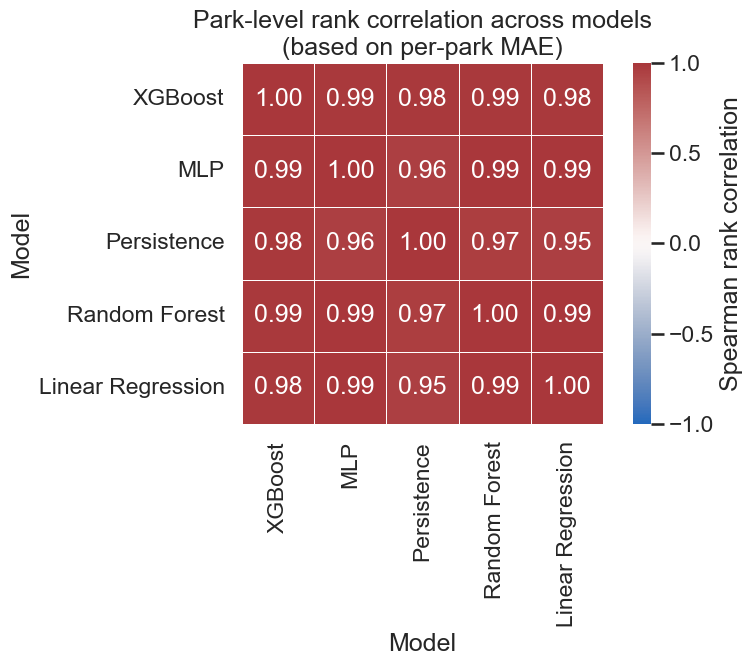

model,XGBoost,MLP,Persistence,Random Forest,Linear Regression
model,,,,,
XGBoost,1.000000,0.990592,0.984542,0.991568,0.984427
MLP,0.990592,1.000000,0.960578,0.993099,0.994145
Persistence,0.984542,0.960578,1.000000,0.968006,0.953824
Random Forest,0.991568,0.993099,0.968006,1.000000,0.992320
Linear Regression,0.984427,0.994145,0.953824,0.992320,1.000000


In [13]:
# ============================================================
# NB09 | Rank-correlation heatmap across models
# ============================================================

park_model_mae_matrix = (
    park_model_metrics_df
    .pivot(index="park_id", columns="model", values="mae")
    .reindex(columns=model_order)
)

if park_model_mae_matrix.isna().any().any():
    raise ValueError("NaN values found in park_model_mae_matrix before correlation analysis.")

# Correlation of park-level model rankings across parks
model_rank_corr_df = park_model_mae_matrix.corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(
    model_rank_corr_df,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman rank correlation"},
)
plt.title("Park-level rank correlation across models\n(based on per-park MAE)")
plt.xlabel("Model")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

display(model_rank_corr_df)

## Deterministic case-study selection logic

Στο επόμενο βήμα, ο στόχος δεν είναι να επιλεγούν «τυχαία ενδιαφέροντα parks», αλλά να δημιουργηθεί ένα **deterministic και reproducible case-study cohort** περίπου 10 parks για thesis-ready figures και park-level interpretation.

### Αρχές επιλογής

Η επιλογή πρέπει να καλύπτει διαφορετικές διαγνωστικές όψεις του benchmark space:

- **easy parks**  
  parks όπου τουλάχιστον ένα model επιτυγχάνει πολύ χαμηλό σφάλμα

- **hard parks**  
  parks όπου ακόμη και το καλύτερο model παραμένει με υψηλό σφάλμα

- **high-bias parks**  
  parks με συστηματική signed απόκλιση, άρα εντονότερη tendency για underprediction ή overprediction

- **high-spread parks**  
  parks με μεγάλη residual variability, άρα πιο ασταθή error structure

- **mid-band fill**  
  parks από το ενδιάμεσο performance band, ώστε το selected cohort να μην περιορίζεται μόνο στα άκρα

### Γιατί deterministic selection

Η deterministic selection είναι σημαντική για:

- reproducibility
- thesis consistency
- anti-cherry-picking support
- καθαρή τεκμηρίωση

### Μεθοδολογικό όριο

Το selected cohort δεν αποτελεί health-labeled ή fault-labeled subset.  
Αποτελεί **diagnostic case-study cohort** μέσα στο forecasting residual space.

In [14]:
# ============================================================
# NB09 | Automatic deterministic selection περίπου 10 parks
# ============================================================

def build_case_study_candidate_table() -> pd.DataFrame:
    candidate_frames = []

    source_map = {
        "hard": hard_parks_df,
        "high_bias": high_bias_parks_df,
        "high_spread": high_spread_parks_df,
        "easy": easy_parks_df,
    }

    for category_name, source_df in source_map.items():
        quota = CATEGORY_QUOTAS[category_name]
        tmp = source_df.head(quota).copy()
        tmp["selection_category"] = category_name
        tmp["category_priority"] = CATEGORY_PRIORITY[category_name]
        candidate_frames.append(tmp)

    candidate_df = pd.concat(candidate_frames, axis=0, ignore_index=True)

    candidate_df["category_sort_metric"] = np.where(
        candidate_df["selection_category"].eq("easy"),
        candidate_df["best_mae"],
        -candidate_df["best_mae"],
    )

    candidate_df = candidate_df.sort_values(
        ["category_priority", "category_sort_metric", "park_id"],
        ascending=[True, True, True],
        kind="mergesort",
    ).reset_index(drop=True)

    candidate_df = candidate_df.drop_duplicates(subset=["park_id"], keep="first").reset_index(drop=True)

    return candidate_df


def build_mid_band_fill_pool(exclude_park_ids: set[str], n_needed: int) -> pd.DataFrame:
    """
    Γεμίζει deterministic το cohort με parks από το μεσαίο performance band,
    ώστε το final set να μη συγκεντρώνεται μόνο στα άκρα.
    """
    if n_needed <= 0:
        return pd.DataFrame(columns=park_difficulty_df.columns.tolist() + ["selection_category", "category_priority"])

    tmp = park_difficulty_df.copy()
    global_median_best_mae = float(tmp["best_mae"].median())
    tmp["distance_to_global_median_best_mae"] = (tmp["best_mae"] - global_median_best_mae).abs()

    tmp = tmp[~tmp["park_id"].isin(exclude_park_ids)].copy()

    tmp = tmp.sort_values(
        ["distance_to_global_median_best_mae", "mean_abs_bias", "park_id"],
        ascending=[True, False, True],
        kind="mergesort",
    ).head(n_needed).reset_index(drop=True)

    tmp["selection_category"] = "mid_band_fill"
    tmp["category_priority"] = CATEGORY_PRIORITY["mid_band_fill"]

    return tmp


auto_candidate_df = build_case_study_candidate_table()

selected_so_far = set(auto_candidate_df["park_id"].tolist())
n_missing = TARGET_SELECTED_PARKS - len(auto_candidate_df)

mid_band_fill_df = build_mid_band_fill_pool(
    exclude_park_ids=selected_so_far,
    n_needed=n_missing,
)

auto_selected_parks_df = pd.concat(
    [auto_candidate_df, mid_band_fill_df],
    axis=0,
    ignore_index=True,
)

auto_selected_parks_df = auto_selected_parks_df.sort_values(
    ["category_priority", "park_id"],
    kind="mergesort",
).reset_index(drop=True)

auto_selected_parks_df["selection_order"] = np.arange(1, len(auto_selected_parks_df) + 1)

if auto_selected_parks_df["park_id"].duplicated().any():
    dup_count = int(auto_selected_parks_df["park_id"].duplicated().sum())
    raise ValueError(f"Duplicate parks found in auto_selected_parks_df: {dup_count}")

if len(auto_selected_parks_df) != TARGET_SELECTED_PARKS:
    raise ValueError(
        f"Automatic case-study selection did not reach target size. "
        f"Expected={TARGET_SELECTED_PARKS}, Found={len(auto_selected_parks_df)}"
    )

AUTO_SELECTED_PARKS = auto_selected_parks_df["park_id"].tolist()

print("Automatic case-study selection completed.")
print(f"AUTO_SELECTED_PARKS = {AUTO_SELECTED_PARKS}")

display(
    auto_selected_parks_df[
        [
            "selection_order",
            "selection_category",
            "park_id",
            "taxonomy_label",
            "best_model_by_mae",
            "best_mae",
            "difficulty_percentile",
            "abs_bias_percentile",
            "residual_std_percentile",
            "winner_margin_stability",
        ]
    ]
)

Automatic case-study selection completed.
AUTO_SELECTED_PARKS = ['02985', '05078', '05792', '02483', '02961', '05426', '01550', '02559', '01078', '05906']


,selection_order,selection_category,park_id,taxonomy_label,best_model_by_mae,best_mae,difficulty_percentile,abs_bias_percentile,residual_std_percentile,winner_margin_stability
0,1,hard,02985,hard,MLP,0.111843,0.992188,0.921875,1.000000,moderate
1,2,hard,05078,hard,Persistence,0.113020,1.000000,0.167969,0.992188,fragile
2,3,hard,05792,hard,Persistence,0.112495,0.996094,0.894531,0.996094,decisive
3,4,high_bias,02483,hard,XGBoost,0.097154,0.964844,0.996094,0.878906,decisive
4,5,high_bias,02961,high_bias,Persistence,0.069237,0.562500,0.992188,0.824219,decisive
5,6,high_bias,05426,hard,Persistence,0.097831,0.968750,1.000000,0.968750,decisive
6,7,easy,01550,easy,Persistence,0.016214,0.003906,0.925781,0.003906,decisive
7,8,easy,02559,easy,Persistence,0.022387,0.007812,0.886719,0.019531,decisive
8,9,mid_band_fill,01078,mixed,XGBoost,0.065456,0.500000,0.335938,0.468750,moderate
9,10,mid_band_fill,05906,mixed,XGBoost,0.065866,0.503906,0.132812,0.562500,moderate


In [15]:
# ============================================================
# NB09 | Manual thesis-oriented override
# ============================================================

# Προεπιλογή: κρατάμε το deterministic automatic cohort.
# Αν αργότερα θέλεις thesis-oriented override, αλλάζεις μόνο αυτή τη λίστα.
MANUAL_SELECTED_PARKS = AUTO_SELECTED_PARKS.copy()

# Παράδειγμα μελλοντικού override:
# MANUAL_SELECTED_PARKS = [
#     "05078", "05426", "02985", "05792", "04271",
#     "01550", "07341", "06211", "02483", "00701",
# ]

if len(MANUAL_SELECTED_PARKS) != TARGET_SELECTED_PARKS:
    raise ValueError(
        f"MANUAL_SELECTED_PARKS must contain exactly {TARGET_SELECTED_PARKS} parks. "
        f"Found={len(MANUAL_SELECTED_PARKS)}"
    )

if len(set(MANUAL_SELECTED_PARKS)) != len(MANUAL_SELECTED_PARKS):
    raise ValueError("MANUAL_SELECTED_PARKS contains duplicates.")

unknown_manual_parks = sorted(set(MANUAL_SELECTED_PARKS) - set(park_difficulty_df["park_id"]))
if unknown_manual_parks:
    raise ValueError(f"Unknown park_ids in MANUAL_SELECTED_PARKS: {unknown_manual_parks}")

selected_park_ids = MANUAL_SELECTED_PARKS.copy()

selected_parks_control_df = pd.DataFrame(
    {
        "selection_order": np.arange(1, len(selected_park_ids) + 1),
        "park_id": selected_park_ids,
        "selection_source": [
            "manual_override" if MANUAL_SELECTED_PARKS != AUTO_SELECTED_PARKS else "automatic_default"
        ] * len(selected_park_ids),
    }
)

print("Final selected park cohort established.")
display(selected_parks_control_df)

Final selected park cohort established.


,selection_order,park_id,selection_source
0,1,02985,automatic_default
1,2,05078,automatic_default
2,3,05792,automatic_default
3,4,02483,automatic_default
4,5,02961,automatic_default
5,6,05426,automatic_default
6,7,01550,automatic_default
7,8,02559,automatic_default
8,9,01078,automatic_default
9,10,05906,automatic_default


In [16]:
# ============================================================
# NB09 | Selected overview, coverage audit και thesis summary
# ============================================================

selected_park_overview_df = (
    selected_parks_control_df
    .merge(
        auto_selected_parks_df[
            [
                "park_id",
                "selection_category",
                "taxonomy_label",
                "best_model_by_mae",
                "best_mae",
                "median_mae",
                "mean_mae",
                "worst_mae",
                "mean_abs_bias",
                "max_abs_bias",
                "mean_residual_std",
                "difficulty_percentile",
                "abs_bias_percentile",
                "residual_std_percentile",
                "winner_margin_mae",
                "winner_margin_relative",
                "winner_margin_stability",
            ]
        ],
        on="park_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values("selection_order", kind="mergesort")
    .reset_index(drop=True)
)

missing_category_mask = selected_park_overview_df["selection_category"].isna()

if missing_category_mask.any():
    fallback_df = (
        park_difficulty_df
        .merge(
            park_best_model_df[["park_id", "best_model_by_mae"]],
            on="park_id",
            how="left",
            validate="one_to_one",
        )
        .copy()
    )
    fallback_df["selection_category"] = "manual_only"

    selected_park_overview_df = (
        selected_park_overview_df.drop(
            columns=[
                "selection_category",
                "taxonomy_label",
                "best_model_by_mae",
                "best_mae",
                "median_mae",
                "mean_mae",
                "worst_mae",
                "mean_abs_bias",
                "max_abs_bias",
                "mean_residual_std",
                "difficulty_percentile",
                "abs_bias_percentile",
                "residual_std_percentile",
                "winner_margin_mae",
                "winner_margin_relative",
                "winner_margin_stability",
            ]
        )
        .merge(
            fallback_df[
                [
                    "park_id",
                    "selection_category",
                    "taxonomy_label",
                    "best_model_by_mae",
                    "best_mae",
                    "median_mae",
                    "mean_mae",
                    "worst_mae",
                    "mean_abs_bias",
                    "max_abs_bias",
                    "mean_residual_std",
                    "difficulty_percentile",
                    "abs_bias_percentile",
                    "residual_std_percentile",
                    "winner_margin_mae",
                    "winner_margin_relative",
                    "winner_margin_stability",
                ]
            ],
            on="park_id",
            how="left",
            validate="one_to_one",
        )
        .sort_values("selection_order", kind="mergesort")
        .reset_index(drop=True)
    )

selected_park_model_metrics_df = (
    park_model_metrics_df[park_model_metrics_df["park_id"].isin(selected_park_ids)]
    .copy()
    .sort_values(["park_id", "park_rank_by_mae", "model"], kind="mergesort")
    .reset_index(drop=True)
)

selected_cohort_coverage_audit_df = (
    selected_park_overview_df
    .merge(
        park_operating_context_df[
            [
                "park_id",
                "mean_wind_level",
                "high_wind_share",
                "mean_power_level",
                "high_power_share",
                "power_std",
                "variability_context",
                "wind_context_column",
            ]
        ],
        on="park_id",
        how="left",
        validate="one_to_one",
    )
    .assign(
        selected_vs_all_difficulty_band=lambda df: df["difficulty_percentile"].apply(classify_percentile_band),
        selected_vs_all_abs_bias_band=lambda df: df["abs_bias_percentile"].apply(classify_percentile_band),
        selected_vs_all_residual_std_band=lambda df: df["residual_std_percentile"].apply(classify_percentile_band),
    )
    .sort_values("selection_order", kind="mergesort")
    .reset_index(drop=True)
)

selected_parks_thesis_summary_df = (
    selected_cohort_coverage_audit_df[
        [
            "selection_order",
            "park_id",
            "selection_source",
            "selection_category",
            "taxonomy_label",
            "best_model_by_mae",
            "best_mae",
            "difficulty_percentile",
            "abs_bias_percentile",
            "residual_std_percentile",
            "winner_margin_mae",
            "winner_margin_stability",
            "mean_wind_level",
            "high_wind_share",
            "mean_power_level",
            "high_power_share",
            "variability_context",
        ]
    ]
    .copy()
)

selected_park_overview_path = NB09_EXPORT_DIR / "nb09_selected_park_overview.csv"
selected_park_model_metrics_path = NB09_EXPORT_DIR / "nb09_selected_park_model_metrics.csv"
selected_park_ids_path = NB09_EXPORT_DIR / "nb09_selected_park_ids.csv"
selected_cohort_coverage_audit_path = NB09_EXPORT_DIR / "nb09_selected_cohort_coverage_audit.csv"
selected_parks_thesis_summary_path = NB09_EXPORT_DIR / "nb09_selected_parks_thesis_summary.csv"

selected_park_overview_df.to_csv(selected_park_overview_path, index=False)
selected_park_model_metrics_df.to_csv(selected_park_model_metrics_path, index=False)
selected_parks_control_df.to_csv(selected_park_ids_path, index=False)
selected_cohort_coverage_audit_df.to_csv(selected_cohort_coverage_audit_path, index=False)
selected_parks_thesis_summary_df.to_csv(selected_parks_thesis_summary_path, index=False)

print("Selected cohort overview and audits exported successfully.")
print(f"- {selected_park_overview_path}")
print(f"- {selected_park_model_metrics_path}")
print(f"- {selected_park_ids_path}")
print(f"- {selected_cohort_coverage_audit_path}")
print(f"- {selected_parks_thesis_summary_path}")

display(selected_parks_thesis_summary_df)

Selected cohort overview and audits exported successfully.
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level\nb09_selected_park_overview.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level\nb09_selected_park_model_metrics.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level\nb09_selected_park_ids.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level\nb09_selected_cohort_coverage_audit.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level\nb09_selected_parks_thesis_summary.csv


,selection_order,park_id,selection_source,selection_category,taxonomy_label,best_model_by_mae,best_mae,difficulty_percentile,abs_bias_percentile,residual_std_percentile,winner_margin_mae,winner_margin_stability,mean_wind_level,high_wind_share,mean_power_level,high_power_share,variability_context
0,1,02985,automatic_default,hard,hard,MLP,0.111843,0.992188,0.921875,1.000000,0.000659,moderate,5.924566,0.149744,0.270478,0.331858,mid_variability
1,2,05078,automatic_default,hard,hard,Persistence,0.113020,1.000000,0.167969,0.992188,0.000422,fragile,8.902941,0.358042,0.293594,0.356177,high_variability
2,3,05792,automatic_default,hard,hard,Persistence,0.112495,0.996094,0.894531,0.996094,0.008321,decisive,2.868590,0.028871,0.496515,0.573458,high_variability
3,4,02483,automatic_default,high_bias,hard,XGBoost,0.097154,0.964844,0.996094,0.878906,0.002380,decisive,7.514301,0.315421,0.482754,0.589953,high_variability
4,5,02961,automatic_default,high_bias,high_bias,Persistence,0.069237,0.562500,0.992188,0.824219,0.003881,decisive,10.305514,0.517611,0.819205,0.893632,mid_variability
5,6,05426,automatic_default,high_bias,hard,Persistence,0.097831,0.968750,1.000000,0.968750,0.005362,decisive,6.136723,0.212107,0.606712,0.698487,high_variability
6,7,01550,automatic_default,easy,easy,Persistence,0.016214,0.003906,0.925781,0.003906,0.004815,decisive,2.631744,0.032829,0.022767,0.012107,low_variability
7,8,02559,automatic_default,easy,easy,Persistence,0.022387,0.007812,0.886719,0.019531,0.003578,decisive,5.502091,0.188591,0.032687,0.019790,low_variability
8,9,01078,automatic_default,mid_band_fill,mixed,XGBoost,0.065456,0.500000,0.335938,0.468750,0.001447,moderate,7.690157,0.281440,0.212304,0.265077,mid_variability
9,10,05906,automatic_default,mid_band_fill,mixed,XGBoost,0.065866,0.503906,0.132812,0.562500,0.000719,moderate,5.953189,0.143423,0.145247,0.153667,mid_variability


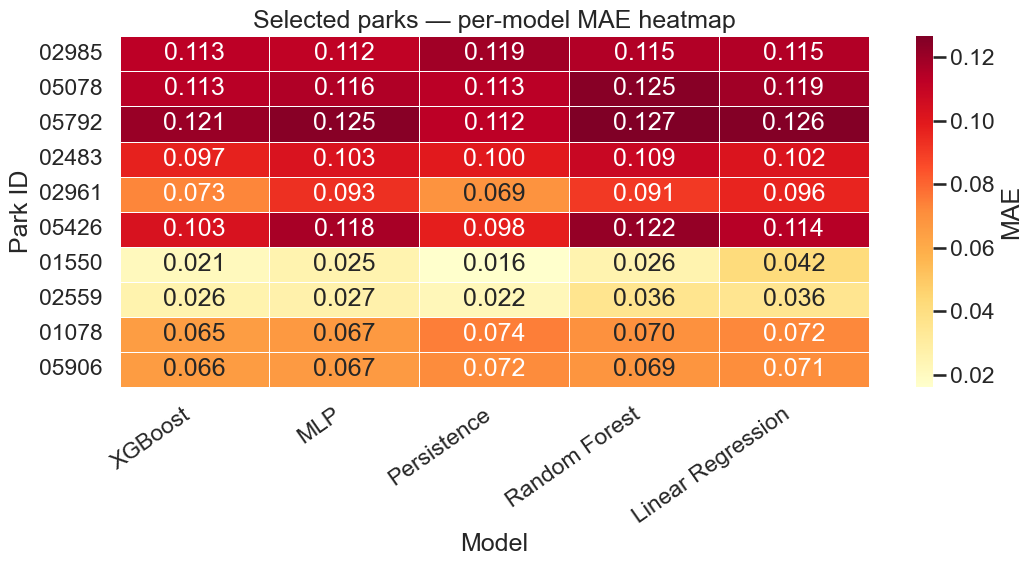

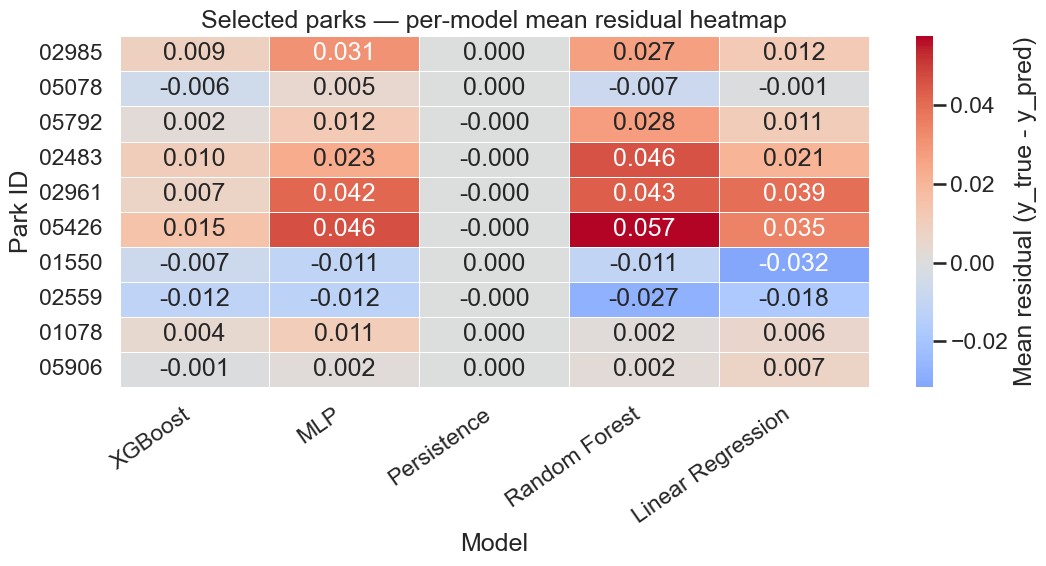

model,XGBoost,MLP,Persistence,Random Forest,Linear Regression
park_id,,,,,
02985,0.112502,0.111843,0.119145,0.115043,0.115292
05078,0.113442,0.115663,0.113020,0.124828,0.119188
05792,0.120817,0.124590,0.112495,0.126597,0.125601
02483,0.097154,0.102554,0.099534,0.108762,0.102272
02961,0.073118,0.093137,0.069237,0.090769,0.096294
05426,0.103193,0.117515,0.097831,0.121688,0.113958
01550,0.021030,0.025435,0.016214,0.025590,0.041964
02559,0.025965,0.026856,0.022387,0.035638,0.035531
01078,0.065456,0.066903,0.074472,0.070031,0.072438


model,XGBoost,MLP,Persistence,Random Forest,Linear Regression
park_id,,,,,
02985,0.008503,0.030641,0.000015,0.026862,0.011572
05078,-0.005757,0.004751,0.000002,-0.007244,-0.000503
05792,0.001926,0.012024,-0.000149,0.027825,0.011021
02483,0.010031,0.023267,-0.000021,0.045889,0.020558
02961,0.006921,0.041525,-0.000081,0.043279,0.039413
05426,0.015004,0.046138,-0.000123,0.057499,0.034732
01550,-0.007036,-0.011086,0.000000,-0.010945,-0.031601
02559,-0.011899,-0.012463,-0.000000,-0.027451,-0.017973
01078,0.004292,0.010526,0.000002,0.001504,0.005737


In [17]:
# ============================================================
# NB09 | Heatmaps για selected parks
# ============================================================

selected_mae_heatmap_df = (
    selected_park_model_metrics_df
    .pivot(index="park_id", columns="model", values="mae")
    .reindex(index=selected_park_ids, columns=model_order)
)

selected_bias_heatmap_df = (
    selected_park_model_metrics_df
    .pivot(index="park_id", columns="model", values="mean_residual")
    .reindex(index=selected_park_ids, columns=model_order)
)

if selected_mae_heatmap_df.isna().any().any():
    raise ValueError("NaN values found in selected_mae_heatmap_df.")

if selected_bias_heatmap_df.isna().any().any():
    raise ValueError("NaN values found in selected_bias_heatmap_df.")

plt.figure(figsize=(11, 6))
sns.heatmap(
    selected_mae_heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "MAE"},
)
plt.title("Selected parks — per-model MAE heatmap")
plt.xlabel("Model")
plt.ylabel("Park ID")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
sns.heatmap(
    selected_bias_heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0.0,
    linewidths=0.5,
    cbar_kws={"label": "Mean residual (y_true - y_pred)"},
)
plt.title("Selected parks — per-model mean residual heatmap")
plt.xlabel("Model")
plt.ylabel("Park ID")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

display(selected_mae_heatmap_df)
display(selected_bias_heatmap_df)

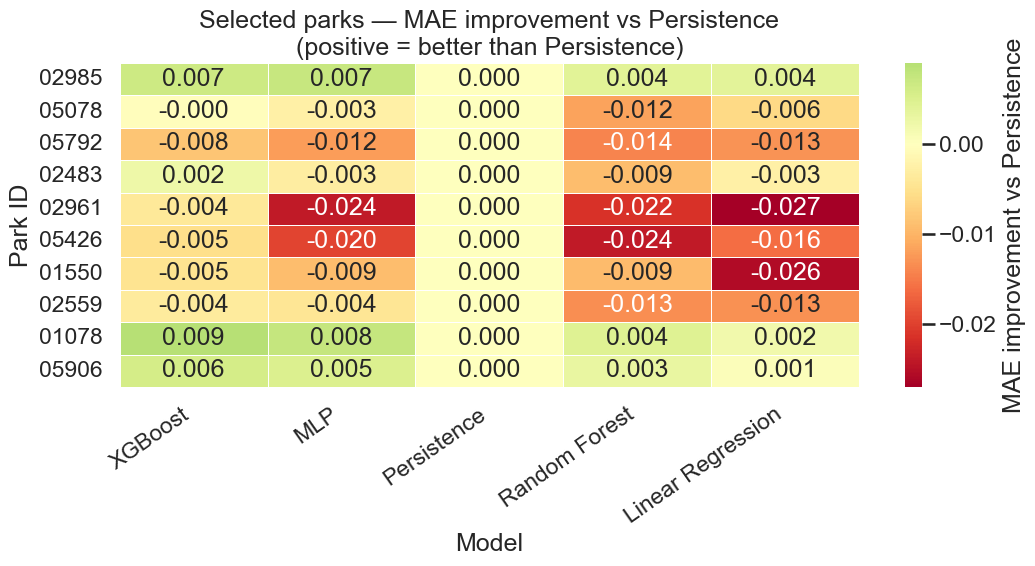

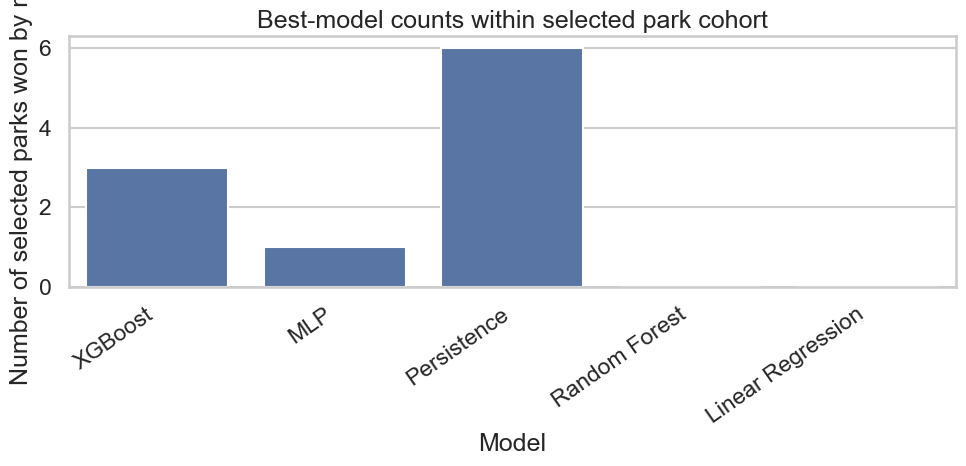

model,XGBoost,MLP,Persistence,Random Forest,Linear Regression
park_id,,,,,
02985,0.006642,0.007302,0.000000,0.004102,0.003853
05078,-0.000422,-0.002643,0.000000,-0.011808,-0.006168
05792,-0.008321,-0.012094,0.000000,-0.014102,-0.013105
02483,0.002380,-0.003020,0.000000,-0.009229,-0.002738
02961,-0.003881,-0.023900,0.000000,-0.021532,-0.027057
05426,-0.005362,-0.019684,0.000000,-0.023858,-0.016127
01550,-0.004815,-0.009220,0.000000,-0.009375,-0.025750
02559,-0.003578,-0.004470,0.000000,-0.013251,-0.013145
01078,0.009016,0.007570,0.000000,0.004441,0.002034


,model,selected_park_count,selected_park_share,all_park_count,all_park_share,mean_winner_margin_mae,median_winner_margin_mae,mean_winner_margin_relative,selected_minus_all_share
0,XGBoost,3,0.300000,197,0.769531,0.001505,0.001417,0.023773,-0.469531
1,MLP,1,0.100000,28,0.109375,0.000483,0.000369,0.008087,-0.009375
2,Persistence,6,0.600000,30,0.117188,0.003116,0.001825,0.058051,0.482812
3,Random Forest,0,0.000000,1,0.003906,0.000137,0.000137,0.001743,-0.003906
4,Linear Regression,0,0.000000,0,0.000000,NaN,NaN,NaN,0.000000


In [18]:
# ============================================================
# NB09 | Improvement vs Persistence + winner counts / shares
# ============================================================

selected_metrics_wide_df = (
    selected_park_model_metrics_df
    .pivot(index="park_id", columns="model", values="mae")
    .reindex(index=selected_park_ids, columns=model_order)
)

if "Persistence" not in selected_metrics_wide_df.columns:
    raise ValueError("Persistence column is missing from selected_metrics_wide_df.")

selected_improvement_vs_persistence_df = selected_metrics_wide_df.copy()

for col in selected_improvement_vs_persistence_df.columns:
    selected_improvement_vs_persistence_df[col] = (
        selected_metrics_wide_df["Persistence"] - selected_metrics_wide_df[col]
    )

selected_improvement_vs_persistence_df["Persistence"] = 0.0

plt.figure(figsize=(11, 6))
sns.heatmap(
    selected_improvement_vs_persistence_df,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0.0,
    linewidths=0.5,
    cbar_kws={"label": "MAE improvement vs Persistence"},
)
plt.title("Selected parks — MAE improvement vs Persistence\n(positive = better than Persistence)")
plt.xlabel("Model")
plt.ylabel("Park ID")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

selected_best_model_counts_df = (
    selected_park_overview_df["best_model_by_mae"]
    .value_counts()
    .reindex(model_order, fill_value=0)
    .rename_axis("model")
    .reset_index(name="selected_park_count")
)

selected_best_model_counts_df["selected_park_share"] = (
    selected_best_model_counts_df["selected_park_count"] / len(selected_park_overview_df)
)

best_model_counts_df = selected_best_model_counts_df.merge(
    all_cohort_best_model_wins_df.rename(
        columns={
            "winner_count": "all_park_count",
            "winner_share": "all_park_share",
        }
    ),
    on="model",
    how="left",
    validate="one_to_one",
)

best_model_counts_df["selected_minus_all_share"] = (
    best_model_counts_df["selected_park_share"] - best_model_counts_df["all_park_share"]
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=best_model_counts_df,
    x="model",
    y="selected_park_count",
    order=model_order,
)
plt.title("Best-model counts within selected park cohort")
plt.xlabel("Model")
plt.ylabel("Number of selected parks won by model")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

display(selected_improvement_vs_persistence_df)
display(best_model_counts_df)

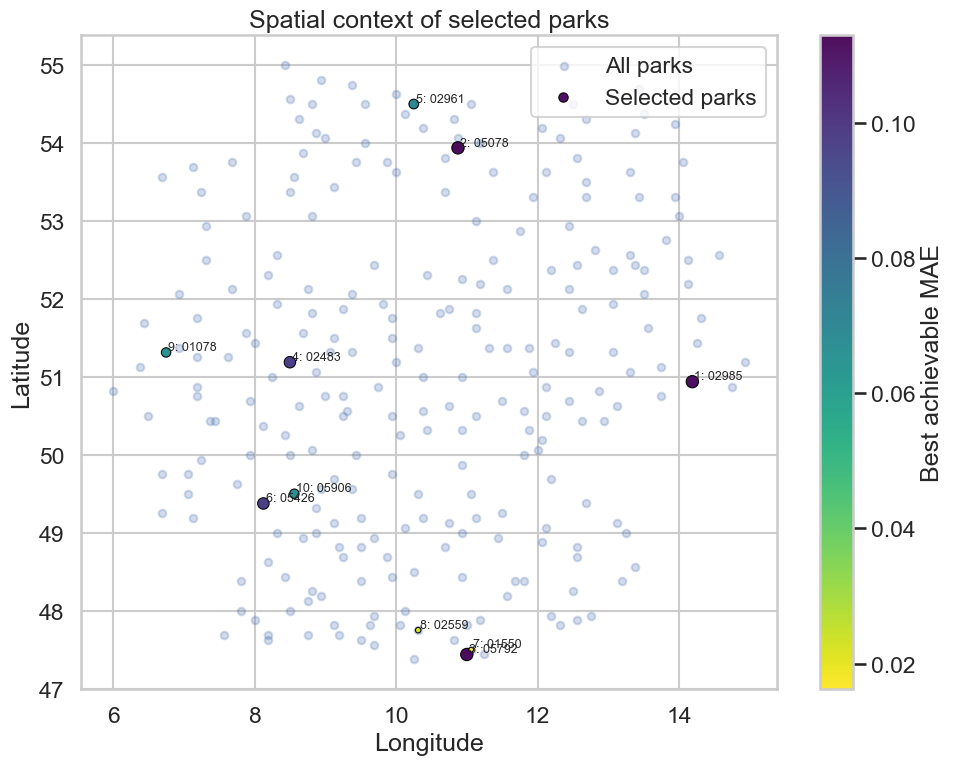

,selection_order,park_id,selection_category,taxonomy_label,best_model_by_mae,best_mae,mean_wind_level,high_wind_share,mean_power_level,high_power_share,variability_context,lat,long
0,1,02985,hard,hard,MLP,0.111843,5.924566,0.149744,0.270478,0.331858,mid_variability,50.937500,14.187500
1,2,05078,hard,hard,Persistence,0.113020,8.902941,0.358042,0.293594,0.356177,high_variability,53.937500,10.875000
2,3,05792,hard,hard,Persistence,0.112495,2.868590,0.028871,0.496515,0.573458,high_variability,47.437500,11.000000
3,4,02483,high_bias,hard,XGBoost,0.097154,7.514301,0.315421,0.482754,0.589953,high_variability,51.187500,8.500000
4,5,02961,high_bias,high_bias,Persistence,0.069237,10.305514,0.517611,0.819205,0.893632,mid_variability,54.500000,10.250000
5,6,05426,high_bias,hard,Persistence,0.097831,6.136723,0.212107,0.606712,0.698487,high_variability,49.375000,8.125000
6,7,01550,easy,easy,Persistence,0.016214,2.631744,0.032829,0.022767,0.012107,low_variability,47.500000,11.062500
7,8,02559,easy,easy,Persistence,0.022387,5.502091,0.188591,0.032687,0.019790,low_variability,47.750000,10.312500
8,9,01078,mid_band_fill,mixed,XGBoost,0.065456,7.690157,0.281440,0.212304,0.265077,mid_variability,51.312500,6.750000
9,10,05906,mid_band_fill,mixed,XGBoost,0.065866,5.953189,0.143423,0.145247,0.153667,mid_variability,49.500000,8.562500


In [19]:
# ============================================================
# NB09 | Spatial scatter / spatial + operating context
# ============================================================

meta_spatial_df = meta_df.copy().rename(columns={"loc_id": "park_id"})

all_parks_spatial_df = (
    park_difficulty_df
    .merge(
        meta_spatial_df[["park_id", "lat", "long"]],
        on="park_id",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        park_best_model_df[["park_id", "best_model_by_mae"]],
        on="park_id",
        how="left",
        validate="one_to_one",
    )
)

selected_spatial_df = (
    selected_cohort_coverage_audit_df
    .merge(
        meta_spatial_df[["park_id", "lat", "long"]],
        on="park_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values("selection_order", kind="mergesort")
    .reset_index(drop=True)
)

missing_selected_coords = selected_spatial_df[["lat", "long"]].isna().any(axis=1).sum()
if missing_selected_coords > 0:
    raise ValueError(
        f"Missing spatial coordinates for {missing_selected_coords} selected parks."
    )

plt.figure(figsize=(10, 8))

plt.scatter(
    all_parks_spatial_df["long"],
    all_parks_spatial_df["lat"],
    s=30,
    alpha=0.25,
    label="All parks",
)

plt.scatter(
    selected_spatial_df["long"],
    selected_spatial_df["lat"],
    s=700 * selected_spatial_df["best_mae"],
    c=selected_spatial_df["best_mae"],
    cmap="viridis_r",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.95,
    label="Selected parks",
)

for _, row in selected_spatial_df.iterrows():
    plt.text(
        row["long"] + 0.03,
        row["lat"] + 0.03,
        f"{row['selection_order']}: {row['park_id']}",
        fontsize=9,
    )

cbar = plt.colorbar()
cbar.set_label("Best achievable MAE")

plt.title("Spatial context of selected parks")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

display(
    selected_spatial_df[
        [
            "selection_order",
            "park_id",
            "selection_category",
            "taxonomy_label",
            "best_model_by_mae",
            "best_mae",
            "mean_wind_level",
            "high_wind_share",
            "mean_power_level",
            "high_power_share",
            "variability_context",
            "lat",
            "long",
        ]
    ]
)

## Case-study figure design

Το επόμενο βήμα είναι η δημιουργία **thesis-ready case-study figures** για κάθε selected park.

### Τι πρέπει να δείχνει κάθε figure

Κάθε case-study figure πρέπει να είναι compact αλλά πληροφοριακά πλήρης, ώστε να λειτουργεί τόσο ερευνητικά όσο και συγγραφικά.

Για κάθε selected park, η figure πρέπει να περιλαμβάνει:

1. **time-window actual vs predicted comparison**  
   σύγκριση `y_true` με τις προβλέψεις των implemented baselines σε deterministic window

2. **residual panel**  
   residual trajectories με sign convention:
   - `residual = y_true - y_pred`

3. **compact park-level context**  
   σύντομο context box με:
   - `park_id`
   - selection category / taxonomy label
   - best model
   - best MAE
   - difficulty / bias / spread percentiles
   - winner-margin stability
   - operating-context descriptors

### Γιατί deterministic window selection

Το window δεν πρέπει να επιλέγεται χειροκίνητα με οπτικό κριτήριο.  
Πρέπει να προκύπτει reproducibly από deterministic logic, ώστε:

- να αποφεύγεται cherry-picking,
- να διατηρείται scientific defensibility,
- και να μπορεί το notebook να ξανατρέξει με το ίδιο αποτέλεσμα.

### Ερμηνευτικός στόχος

Οι case-study figures δεν χρησιμοποιούνται για να αποδείξουν fault events.  
Χρησιμοποιούνται για να δείξουν:

- πώς αλλάζει η ποιότητα πρόβλεψης ανά park,
- πώς εμφανίζεται η bias structure,
- πώς μεταβάλλεται η winner stability,
- και πώς η forecasting residual behavior μπορεί να υποστηρίξει diagnostics-aware discussion.

In [20]:
# ============================================================
# NB09 | Helpers για deterministic case-study window selection
# ============================================================

CASE_STUDY_WINDOW_HOURS = 72
CASE_STUDY_SCORING_ROLLING_HOURS = 24
CASE_STUDY_MIN_PERIODS = 12

CASE_STUDY_FIGURE_DIR = NB09_EXPORT_DIR / "figures" / "case_studies"
CASE_STUDY_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def get_selected_park_context(park_id: str) -> pd.Series:
    row = selected_cohort_coverage_audit_df.loc[selected_cohort_coverage_audit_df["park_id"] == park_id]
    if len(row) != 1:
        raise ValueError(f"Expected exactly one selected_cohort_coverage row for park_id={park_id}")
    return row.iloc[0]


def build_single_park_analysis_df(park_id: str) -> pd.DataFrame:
    df = (
        analysis_df.loc[analysis_df["park_id"] == park_id]
        .copy()
        .sort_values(["timestamp", "model"], kind="mergesort")
        .reset_index(drop=True)
    )

    if df.empty:
        raise ValueError(f"No analysis rows found for park_id={park_id}")

    found_models = sorted(df["model"].unique().tolist())
    if set(found_models) != set(CANONICAL_MODELS):
        raise ValueError(
            f"Park {park_id} does not contain the full canonical model set. "
            f"Found={found_models}"
        )

    per_model_counts = df.groupby("model", observed=True)["timestamp"].nunique()
    if per_model_counts.nunique() != 1:
        raise ValueError(
            f"Park {park_id} has inconsistent timestamp coverage across models: "
            f"{per_model_counts.to_dict()}"
        )

    return df


def select_deterministic_case_study_window(
    park_id: str,
    window_hours: int = CASE_STUDY_WINDOW_HOURS,
    scoring_rolling_hours: int = CASE_STUDY_SCORING_ROLLING_HOURS,
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    """
    Επιλέγει deterministic case-study window με βάση τη δυσκολία του park
    στο συγκεκριμένο test period.

    Scoring logic:
    - υπολογίζουμε ανά timestamp το mean abs_error across models
    - κάνουμε centered rolling smoothing
    - επιλέγουμε το peak difficulty timestamp
    - ανοίγουμε fixed-size window γύρω από αυτό
    """
    park_df = build_single_park_analysis_df(park_id)

    timestamp_score_df = (
        park_df.groupby("timestamp", observed=True)
        .agg(
            y_true=("y_true", "first"),
            mean_abs_error_all_models=("abs_error", "mean"),
            max_abs_error_all_models=("abs_error", "max"),
            mean_signed_residual_all_models=("residual", "mean"),
        )
        .reset_index()
        .sort_values("timestamp", kind="mergesort")
        .reset_index(drop=True)
    )

    timestamp_score_df["difficulty_score"] = (
        timestamp_score_df["mean_abs_error_all_models"]
        .rolling(
            window=scoring_rolling_hours,
            min_periods=CASE_STUDY_MIN_PERIODS,
            center=True,
        )
        .mean()
    )

    timestamp_score_df["difficulty_score"] = timestamp_score_df["difficulty_score"].fillna(
        timestamp_score_df["mean_abs_error_all_models"]
    )

    peak_idx = int(timestamp_score_df["difficulty_score"].idxmax())
    peak_timestamp = timestamp_score_df.loc[peak_idx, "timestamp"]

    half_window = window_hours // 2
    start_ts = peak_timestamp - pd.Timedelta(hours=half_window)
    end_ts = peak_timestamp + pd.Timedelta(hours=(window_hours - half_window - 1))

    ts_min = timestamp_score_df["timestamp"].min()
    ts_max = timestamp_score_df["timestamp"].max()

    if start_ts < ts_min:
        shift = ts_min - start_ts
        start_ts = start_ts + shift
        end_ts = end_ts + shift

    if end_ts > ts_max:
        shift = end_ts - ts_max
        start_ts = start_ts - shift
        end_ts = end_ts - shift

    start_ts = max(start_ts, ts_min)
    end_ts = min(end_ts, ts_max)

    window_df = (
        park_df.loc[
            (park_df["timestamp"] >= start_ts) &
            (park_df["timestamp"] <= end_ts)
        ]
        .copy()
        .sort_values(["timestamp", "model"], kind="mergesort")
        .reset_index(drop=True)
    )

    if window_df.empty:
        raise ValueError(f"Selected window is empty for park_id={park_id}")

    context = get_selected_park_context(park_id)

    metadata = {
        "park_id": park_id,
        "selection_order": int(context["selection_order"]),
        "selection_category": context["selection_category"],
        "taxonomy_label": context["taxonomy_label"],
        "best_model_by_mae": context["best_model_by_mae"],
        "best_mae": float(context["best_mae"]),
        "difficulty_percentile": float(context["difficulty_percentile"]),
        "abs_bias_percentile": float(context["abs_bias_percentile"]),
        "residual_std_percentile": float(context["residual_std_percentile"]),
        "winner_margin_mae": float(context["winner_margin_mae"]),
        "winner_margin_stability": context["winner_margin_stability"],
        "mean_wind_level": float(context["mean_wind_level"]) if pd.notna(context["mean_wind_level"]) else np.nan,
        "high_wind_share": float(context["high_wind_share"]) if pd.notna(context["high_wind_share"]) else np.nan,
        "mean_power_level": float(context["mean_power_level"]),
        "high_power_share": float(context["high_power_share"]),
        "variability_context": context["variability_context"],
        "window_hours": int(window_hours),
        "rolling_hours": int(scoring_rolling_hours),
        "peak_timestamp": peak_timestamp,
        "window_start": start_ts,
        "window_end": end_ts,
        "peak_difficulty_score": float(timestamp_score_df.loc[peak_idx, "difficulty_score"]),
        "n_window_rows": int(len(window_df)),
        "n_window_timestamps": int(window_df["timestamp"].nunique()),
    }

    return window_df, timestamp_score_df, metadata


print("Case-study window helper layer initialized.")

Case-study window helper layer initialized.


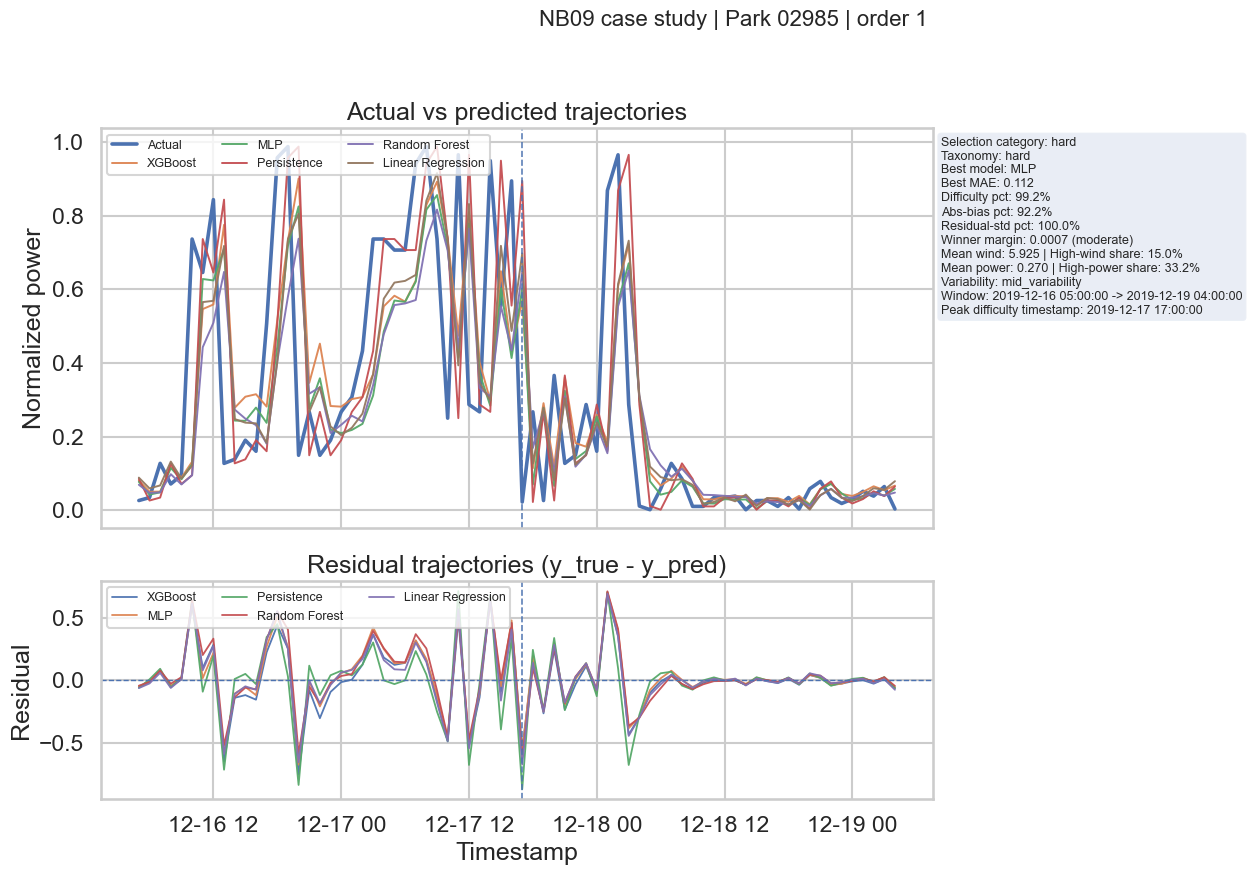

,park_id,selection_order,selection_category,taxonomy_label,best_model_by_mae,best_mae,difficulty_percentile,abs_bias_percentile,residual_std_percentile,winner_margin_mae,winner_margin_stability,mean_wind_level,high_wind_share,mean_power_level,high_power_share,variability_context,window_hours,rolling_hours,peak_timestamp,window_start,window_end,peak_difficulty_score,n_window_rows,n_window_timestamps
0,02985,1,hard,hard,MLP,0.111843,0.992188,0.921875,1.000000,0.000659,moderate,5.924566,0.149744,0.270478,0.331858,mid_variability,72,24,2019-12-17 17:00:00,2019-12-16 05:00:00,2019-12-19 04:00:00,0.305496,360,72


In [21]:
# ============================================================
# NB09 | Thesis-ready case-study figure generator for one park
# ============================================================

def plot_single_park_case_study_figure(
    park_id: str,
    window_hours: int = CASE_STUDY_WINDOW_HOURS,
    scoring_rolling_hours: int = CASE_STUDY_SCORING_ROLLING_HOURS,
    show_figure: bool = True,
):
    window_df, timestamp_score_df, metadata = select_deterministic_case_study_window(
        park_id=park_id,
        window_hours=window_hours,
        scoring_rolling_hours=scoring_rolling_hours,
    )

    actual_df = (
        window_df[["timestamp", "y_true"]]
        .drop_duplicates(subset=["timestamp"])
        .sort_values("timestamp", kind="mergesort")
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(15, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.2]},
    )

    axes[0].plot(
        actual_df["timestamp"],
        actual_df["y_true"],
        linewidth=2.6,
        label="Actual",
    )

    for model_name in model_order:
        model_df = (
            window_df.loc[window_df["model"] == model_name]
            .sort_values("timestamp", kind="mergesort")
            .reset_index(drop=True)
        )
        axes[0].plot(
            model_df["timestamp"],
            model_df["y_pred"],
            linewidth=1.4,
            alpha=0.95,
            label=model_name,
        )

    axes[0].axvline(
        metadata["peak_timestamp"],
        linestyle="--",
        linewidth=1.2,
        alpha=0.9,
    )

    axes[0].set_ylabel("Normalized power")
    axes[0].set_title("Actual vs predicted trajectories")

    for model_name in model_order:
        model_df = (
            window_df.loc[window_df["model"] == model_name]
            .sort_values("timestamp", kind="mergesort")
            .reset_index(drop=True)
        )
        axes[1].plot(
            model_df["timestamp"],
            model_df["residual"],
            linewidth=1.3,
            alpha=0.95,
            label=model_name,
        )

    axes[1].axhline(
        0.0,
        linestyle="--",
        linewidth=1.0,
    )
    axes[1].axvline(
        metadata["peak_timestamp"],
        linestyle="--",
        linewidth=1.2,
        alpha=0.9,
    )

    axes[1].set_ylabel("Residual")
    axes[1].set_xlabel("Timestamp")
    axes[1].set_title("Residual trajectories (y_true - y_pred)")

    wind_text = (
        "n/a"
        if pd.isna(metadata["mean_wind_level"])
        else f"{metadata['mean_wind_level']:.3f}"
    )
    high_wind_share_text = (
        "n/a"
        if pd.isna(metadata["high_wind_share"])
        else f"{metadata['high_wind_share']:.1%}"
    )

    context_text = (
        f"Selection category: {metadata['selection_category']}\n"
        f"Taxonomy: {metadata['taxonomy_label']}\n"
        f"Best model: {metadata['best_model_by_mae']}\n"
        f"Best MAE: {metadata['best_mae']:.3f}\n"
        f"Difficulty pct: {metadata['difficulty_percentile']:.1%}\n"
        f"Abs-bias pct: {metadata['abs_bias_percentile']:.1%}\n"
        f"Residual-std pct: {metadata['residual_std_percentile']:.1%}\n"
        f"Winner margin: {metadata['winner_margin_mae']:.4f} ({metadata['winner_margin_stability']})\n"
        f"Mean wind: {wind_text} | High-wind share: {high_wind_share_text}\n"
        f"Mean power: {metadata['mean_power_level']:.3f} | High-power share: {metadata['high_power_share']:.1%}\n"
        f"Variability: {metadata['variability_context']}\n"
        f"Window: {metadata['window_start']} -> {metadata['window_end']}\n"
        f"Peak difficulty timestamp: {metadata['peak_timestamp']}"
    )

    axes[0].text(
        1.01,
        0.98,
        context_text,
        transform=axes[0].transAxes,
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", alpha=0.12),
    )

    axes[0].legend(loc="upper left", ncol=3, fontsize=9)
    axes[1].legend(loc="upper left", ncol=3, fontsize=9)

    fig.suptitle(
        f"NB09 case study | Park {park_id} | order {metadata['selection_order']}",
        fontsize=16,
        y=0.98,
    )

    fig.tight_layout(rect=[0, 0, 0.86, 0.96])

    if show_figure:
        plt.show()

    return fig, window_df, metadata


DEMO_PARK_ID = selected_park_ids[0]

demo_fig, demo_window_df, demo_case_study_metadata = plot_single_park_case_study_figure(
    park_id=DEMO_PARK_ID,
    show_figure=True,
)

display(pd.DataFrame([demo_case_study_metadata]))

In [22]:
# ============================================================
# NB09 | Loop για all selected case-study figures
# ============================================================

case_study_export_records = []

for park_id in selected_park_ids:
    fig, park_window_df, metadata = plot_single_park_case_study_figure(
        park_id=park_id,
        show_figure=False,
    )

    figure_path = CASE_STUDY_FIGURE_DIR / (
        f"nb09_case_study_{metadata['selection_order']:02d}_{park_id}.png"
    )

    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    export_record = metadata.copy()
    export_record["figure_path"] = str(figure_path)
    export_record["n_models"] = int(park_window_df["model"].nunique())
    case_study_export_records.append(export_record)

case_study_window_metadata_df = (
    pd.DataFrame(case_study_export_records)
    .sort_values(["selection_order", "park_id"], kind="mergesort")
    .reset_index(drop=True)
)

case_study_window_metadata_path = (
    NB09_EXPORT_DIR / "nb09_case_study_window_metadata.csv"
)
case_study_window_metadata_df.to_csv(case_study_window_metadata_path, index=False)

print("All selected case-study figures exported successfully.")
print(f"Case-study figure directory: {CASE_STUDY_FIGURE_DIR}")
print(f"Window metadata path       : {case_study_window_metadata_path}")

display(case_study_window_metadata_df)

All selected case-study figures exported successfully.
Case-study figure directory: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level\figures\case_studies
Window metadata path       : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level\nb09_case_study_window_metadata.csv


,park_id,selection_order,selection_category,taxonomy_label,best_model_by_mae,best_mae,difficulty_percentile,abs_bias_percentile,residual_std_percentile,winner_margin_mae,winner_margin_stability,mean_wind_level,high_wind_share,mean_power_level,high_power_share,variability_context,window_hours,rolling_hours,peak_timestamp,window_start,window_end,peak_difficulty_score,n_window_rows,n_window_timestamps,figure_path,n_models
0,02985,1,hard,hard,MLP,0.111843,0.992188,0.921875,1.000000,0.000659,moderate,5.924566,0.149744,0.270478,0.331858,mid_variability,72,24,2019-12-17 17:00:00,2019-12-16 05:00:00,2019-12-19 04:00:00,0.305496,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
1,05078,2,hard,hard,Persistence,0.113020,1.000000,0.167969,0.992188,0.000422,fragile,8.902941,0.358042,0.293594,0.356177,high_variability,72,24,2020-02-10 14:00:00,2020-02-09 02:00:00,2020-02-12 01:00:00,0.309883,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
2,05792,3,hard,hard,Persistence,0.112495,0.996094,0.894531,0.996094,0.008321,decisive,2.868590,0.028871,0.496515,0.573458,high_variability,72,24,2020-05-12 02:00:00,2020-05-10 14:00:00,2020-05-13 13:00:00,0.261825,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
3,02483,4,high_bias,hard,XGBoost,0.097154,0.964844,0.996094,0.878906,0.002380,decisive,7.514301,0.315421,0.482754,0.589953,high_variability,72,24,2019-12-17 07:00:00,2019-12-15 19:00:00,2019-12-18 18:00:00,0.236137,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
4,02961,5,high_bias,high_bias,Persistence,0.069237,0.562500,0.992188,0.824219,0.003881,decisive,10.305514,0.517611,0.819205,0.893632,mid_variability,72,24,2020-05-01 09:00:00,2020-04-29 21:00:00,2020-05-02 20:00:00,0.278117,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
5,05426,6,high_bias,hard,Persistence,0.097831,0.968750,1.000000,0.968750,0.005362,decisive,6.136723,0.212107,0.606712,0.698487,high_variability,72,24,2019-12-12 19:00:00,2019-12-11 07:00:00,2019-12-14 06:00:00,0.272481,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
6,01550,7,easy,easy,Persistence,0.016214,0.003906,0.925781,0.003906,0.004815,decisive,2.631744,0.032829,0.022767,0.012107,low_variability,72,24,2020-02-23 18:00:00,2020-02-22 06:00:00,2020-02-25 05:00:00,0.166303,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
7,02559,8,easy,easy,Persistence,0.022387,0.007812,0.886719,0.019531,0.003578,decisive,5.502091,0.188591,0.032687,0.019790,low_variability,72,24,2020-02-11 14:00:00,2020-02-10 02:00:00,2020-02-13 01:00:00,0.224884,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
8,01078,9,mid_band_fill,mixed,XGBoost,0.065456,0.500000,0.335938,0.468750,0.001447,moderate,7.690157,0.281440,0.212304,0.265077,mid_variability,72,24,2020-02-25 19:00:00,2020-02-24 07:00:00,2020-02-27 06:00:00,0.222760,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
9,05906,10,mid_band_fill,mixed,XGBoost,0.065866,0.503906,0.132812,0.562500,0.000719,moderate,5.953189,0.143423,0.145247,0.153667,mid_variability,72,24,2020-03-13 07:00:00,2020-03-11 19:00:00,2020-03-14 18:00:00,0.254982,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5


In [23]:
# ============================================================
# NB09 | Export NB09 artifacts
# ============================================================

nb09_export_frames = {
    "nb09_park_model_metrics.csv": park_model_metrics_df,
    "nb09_park_difficulty_summary.csv": park_difficulty_df,
    "nb09_park_best_model_summary.csv": park_best_model_df,
    "nb09_all_cohort_best_model_wins.csv": all_cohort_best_model_wins_df,
    "nb09_park_operating_context.csv": park_operating_context_df,
    "nb09_park_taxonomy_manifest.csv": park_difficulty_df[
        [
            "park_id",
            "best_model_by_mae",
            "best_mae",
            "difficulty_percentile",
            "abs_bias_percentile",
            "residual_std_percentile",
            "winner_margin_mae",
            "winner_margin_relative",
            "winner_margin_stability",
            "taxonomy_label",
            "is_easy_candidate",
            "is_hard_candidate",
            "is_high_bias_candidate",
            "is_high_spread_candidate",
        ]
    ].copy(),
    "nb09_model_rank_correlation.csv": model_rank_corr_df.reset_index(),
    "nb09_selected_mae_heatmap_matrix.csv": selected_mae_heatmap_df.reset_index(),
    "nb09_selected_bias_heatmap_matrix.csv": selected_bias_heatmap_df.reset_index(),
    "nb09_selected_improvement_vs_persistence.csv": selected_improvement_vs_persistence_df.reset_index(),
    "nb09_selected_best_model_counts.csv": best_model_counts_df,
    "nb09_selected_spatial_context.csv": selected_spatial_df,
    "nb09_selected_cohort_coverage_audit.csv": selected_cohort_coverage_audit_df,
    "nb09_selected_parks_thesis_summary.csv": selected_parks_thesis_summary_df,
    "nb09_case_study_window_metadata.csv": case_study_window_metadata_df,
}

artifact_group_map = {
    "nb09_park_model_metrics.csv": ("all_cohort_metrics", "Per-park per-model diagnostic metrics on the canonical test-only space."),
    "nb09_park_difficulty_summary.csv": ("all_cohort_metrics", "Per-park difficulty, bias, spread and winner-margin summary."),
    "nb09_park_best_model_summary.csv": ("all_cohort_metrics", "Best model per park under MAE ranking."),
    "nb09_all_cohort_best_model_wins.csv": ("all_cohort_metrics", "Winner counts and shares across all parks."),
    "nb09_park_operating_context.csv": ("operating_context", "Mean wind/power descriptors and variability context per park."),
    "nb09_park_taxonomy_manifest.csv": ("operating_context", "Explicit percentile-based taxonomy manifest for all parks."),
    "nb09_model_rank_correlation.csv": ("comparative_analysis", "Spearman rank correlation across model park-level MAE profiles."),
    "nb09_selected_mae_heatmap_matrix.csv": ("selected_cohort", "Selected-park MAE heatmap matrix."),
    "nb09_selected_bias_heatmap_matrix.csv": ("selected_cohort", "Selected-park mean-residual heatmap matrix."),
    "nb09_selected_improvement_vs_persistence.csv": ("selected_cohort", "Selected-park improvement table versus Persistence."),
    "nb09_selected_best_model_counts.csv": ("selected_cohort", "Winner counts and shares for selected parks versus all parks."),
    "nb09_selected_spatial_context.csv": ("selected_cohort", "Spatial and operating context for selected parks."),
    "nb09_selected_cohort_coverage_audit.csv": ("selected_cohort", "Selected parks with percentile-based coverage audit."),
    "nb09_selected_parks_thesis_summary.csv": ("selected_cohort", "Compact thesis-ready selected-park summary."),
    "nb09_case_study_window_metadata.csv": ("case_studies", "Deterministic case-study window metadata for each selected park."),
}

export_manifest_records = []

for file_name, df_obj in nb09_export_frames.items():
    export_path = NB09_EXPORT_DIR / file_name
    df_obj.to_csv(export_path, index=False)

    artifact_group, purpose = artifact_group_map[file_name]
    export_manifest_records.append(
        {
            "file_name": file_name,
            "path": str(export_path),
            "rows": int(df_obj.shape[0]),
            "cols": int(df_obj.shape[1]),
            "artifact_group": artifact_group,
            "purpose": purpose,
        }
    )

preexisting_exports = [
    selected_park_overview_path,
    selected_park_model_metrics_path,
    selected_park_ids_path,
]

preexisting_purpose_map = {
    "nb09_selected_park_overview.csv": ("selected_cohort", "Selected-park overview with deterministic selection metadata."),
    "nb09_selected_park_model_metrics.csv": ("selected_cohort", "Per-model metrics for selected parks only."),
    "nb09_selected_park_ids.csv": ("selected_cohort", "Deterministic selected-park control table."),
}

for existing_path in preexisting_exports:
    artifact_group, purpose = preexisting_purpose_map[existing_path.name]
    tmp_df = pd.read_csv(existing_path)

    export_manifest_records.append(
        {
            "file_name": existing_path.name,
            "path": str(existing_path),
            "rows": int(tmp_df.shape[0]),
            "cols": int(tmp_df.shape[1]),
            "artifact_group": artifact_group,
            "purpose": purpose,
        }
    )

nb09_export_manifest_df = (
    pd.DataFrame(export_manifest_records)
    .sort_values(["artifact_group", "file_name"], kind="mergesort")
    .reset_index(drop=True)
)

nb09_export_manifest_path = NB09_EXPORT_DIR / "nb09_export_manifest.csv"
nb09_export_manifest_df.to_csv(nb09_export_manifest_path, index=False)

print("NB09 artifact export completed successfully.")
print(f"Export manifest path: {nb09_export_manifest_path}")

display(nb09_export_manifest_df)

NB09 artifact export completed successfully.
Export manifest path: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level\nb09_export_manifest.csv


,file_name,path,rows,cols,artifact_group,purpose
0,nb09_all_cohort_best_model_wins.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5,6,all_cohort_metrics,Winner counts and shares across all parks.
1,nb09_park_best_model_summary.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,256,22,all_cohort_metrics,Best model per park under MAE ranking.
2,nb09_park_difficulty_summary.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,256,25,all_cohort_metrics,"Per-park difficulty, bias, spread and winner-m..."
3,nb09_park_model_metrics.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,1280,22,all_cohort_metrics,Per-park per-model diagnostic metrics on the c...
4,nb09_case_study_window_metadata.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,10,26,case_studies,Deterministic case-study window metadata for e...
5,nb09_model_rank_correlation.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5,6,comparative_analysis,Spearman rank correlation across model park-le...
6,nb09_park_operating_context.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,256,13,operating_context,Mean wind/power descriptors and variability co...
7,nb09_park_taxonomy_manifest.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,256,14,operating_context,Explicit percentile-based taxonomy manifest fo...
8,nb09_selected_best_model_counts.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5,9,selected_cohort,Winner counts and shares for selected parks ve...
9,nb09_selected_bias_heatmap_matrix.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,10,6,selected_cohort,Selected-park mean-residual heatmap matrix.


## Scientific interpretation

Το `NB09` επεκτείνει το diagnostics layer από το row-level residual space σε **park-level diagnostic consolidation** πάνω στο κοινό **test-only evaluation space**.

### Implemented now

Στην παρούσα strengthened εκδοχή του notebook υλοποιούνται πλέον ρητά:

- per-park diagnostic aggregation across all implemented baselines,
- all-cohort winner counts και winner shares,
- winner-margin stability ανά park,
- explicit percentile framing για difficulty / abs_bias / residual_std,
- full taxonomy manifest (`easy / hard / high-bias / high-spread / mixed`),
- operating-context descriptors ανά park,
- selected-cohort coverage audit,
- deterministic thesis-ready case-study exports.

### Cautious interpretation

1. **Η σχετική δυσκολία των parks παραμένει σε μεγάλο βαθμό δομημένη.**  
   Η rank correlation και η επαναλαμβανόμενη παρουσία συγκεκριμένων parks στα difficult / easy tails δείχνουν ότι η park-level δυσκολία δεν είναι απλό τυχαίο artefact.

2. **Το aggregate benchmark δεν αρκεί για πλήρη ερμηνεία.**  
   Το `baseline_metrics.csv` παραμένει η canonical authority για τη συνολική ranking, αλλά το park-level layer δείχνει ότι η model superiority δεν κατανέμεται ομοιόμορφα στο cohort.

3. **Η νίκη του best model δεν έχει παντού την ίδια σταθερότητα.**  
   Το winner-margin layer ξεχωρίζει parks όπου ο νικητής είναι σχετικά αποφασιστικός από parks όπου η υπεροχή του είναι πιο εύθραυστη.

4. **Το selected cohort είναι πιο defensible.**  
   Με explicit percentiles, taxonomy coverage και operating-context descriptors, το selected case-study cohort υποστηρίζεται καλύτερα απέναντι σε cherry-picking objections.

5. **Η diagnostics-aware γέφυρα γίνεται πιο ώριμη αλλά παραμένει bounded.**  
   Το notebook επιτρέπει πιο ώριμη condition-awareness-oriented discussion, χωρίς να μετατρέπει τα ευρήματα σε fault / anomaly / prognostics claims.

### Future work / research extension

Τα παρακάτω **δεν** αποτελούν μέρος του implemented scope του `NB09`:

- graph-based forecasting models
- sequence-based forecasting models
- stronger uncertainty-aware diagnostics
- validated anomaly / fault workflows
- broader PHM-oriented inference layer

## Limitations

Παρά τη χρησιμότητα του strengthened park-level diagnostics layer, υπάρχουν σαφή methodological limits που πρέπει να δηλωθούν ρητά.

### 1. Forecasting diagnostics και όχι completed PHM module
Το `NB09` παραμένει αυστηρά **forecasting-downstream diagnostics notebook**.  
Τα residuals και τα park-level error patterns μπορούν να συζητηθούν ως **diagnostic signal candidates**, αλλά όχι ως αποδείξεις fault states, degradation mechanisms ή prognostic functionality.

### 2. Συνθετικό dataset
Η ανάλυση βασίζεται στο **DaKS / Kassel synthetic wind power dataset**.  
Άρα η μετάβαση από residual structure σε πραγματική turbine health inference απαιτεί πρόσθετη επιβεβαίωση σε real operational settings.

### 3. Park-level aggregation
Η aggregation σε επίπεδο park είναι ερμηνευτικά χρήσιμη, αλλά συμπιέζει την ετερογένεια του time axis.  
Το park-level summary δεν αντικαθιστά λεπτομερή χρονική ανάλυση ούτε περιγράφει όλα τα transient regimes.

### 4. Deterministic case-study windows
Τα case-study windows επιλέγονται deterministically ώστε να αποφεύγεται cherry-picking.  
Παρόλα αυτά, κάθε fixed-window representation παραμένει μερική απεικόνιση της συνολικής συμπεριφοράς ενός park.

### 5. Current model family
Τα συμπεράσματα του `NB09` αφορούν το current implemented tabular benchmark stack:
- Persistence
- Linear Regression
- Random Forest
- XGBoost
- MLP

Δεν αποτελούν evidence για graph-based ή sequence-based superiority.

### 6. Descriptive και όχι causal layer
Το spatial context, τα operating descriptors και η taxonomy διαφοροποίηση είναι descriptive / diagnostic εργαλεία και όχι causal attribution study.

## Conclusion

Το strengthened `NB09` ολοκληρώνει ένα πιο ώριμο επίπεδο του downstream diagnostics stack, μεταφέροντας την ερμηνεία από το row-level residual space σε **park-level benchmark-aware diagnostics** με πιο αυστηρό thesis-facing wording.

### Τι δείχνει το notebook

- τα aggregate benchmark metrics είναι αναγκαία αλλά όχι επαρκή,
- η δυσκολία πρόβλεψης διαφέρει συστηματικά ανά park,
- η winner stability διαφέρει επίσης ανά park,
- ορισμένα parks εμφανίζουν ισχυρότερη bias ή spread structure,
- και ένα selected cohort μπορεί να τεκμηριωθεί πιο καθαρά με percentiles, taxonomy και operating-context descriptors.

### What is implemented now
- canonical benchmark-safe park-level aggregation
- all-cohort winner counts / shares
- winner-margin stability
- percentile-based taxonomy manifest
- operating-context descriptors
- selected cohort coverage audit
- deterministic thesis-ready case-study figures and exports

### What remains future work
- graph-based forecasting models
- sequence-based models
- stronger uncertainty-aware diagnostics
- broader PHM-oriented research extension
- deeper digital-twin integration beyond the current forecasting diagnostics scope

Η συνολική θέση του notebook παραμένει:

**forecasting-first, benchmark-safe, diagnostics-aware, thesis-facing**

και όχι completed PHM / anomaly / fault / prognostics functionality.

In [24]:
# ============================================================
# NB09 | Final sanity summary
# ============================================================

required_nb09_exports = [
    NB09_EXPORT_DIR / "nb09_export_manifest.csv",
    NB09_EXPORT_DIR / "nb09_park_model_metrics.csv",
    NB09_EXPORT_DIR / "nb09_park_difficulty_summary.csv",
    NB09_EXPORT_DIR / "nb09_park_best_model_summary.csv",
    NB09_EXPORT_DIR / "nb09_all_cohort_best_model_wins.csv",
    NB09_EXPORT_DIR / "nb09_park_operating_context.csv",
    NB09_EXPORT_DIR / "nb09_park_taxonomy_manifest.csv",
    NB09_EXPORT_DIR / "nb09_selected_park_overview.csv",
    NB09_EXPORT_DIR / "nb09_selected_park_model_metrics.csv",
    NB09_EXPORT_DIR / "nb09_selected_park_ids.csv",
    NB09_EXPORT_DIR / "nb09_selected_cohort_coverage_audit.csv",
    NB09_EXPORT_DIR / "nb09_selected_parks_thesis_summary.csv",
    NB09_EXPORT_DIR / "nb09_case_study_window_metadata.csv",
]

missing_nb09_exports = [str(p) for p in required_nb09_exports if not p.exists()]

figure_files = sorted(CASE_STUDY_FIGURE_DIR.glob("nb09_case_study_*.png"))

final_summary = {
    "analysis_rows": int(len(analysis_df)),
    "analysis_models": int(analysis_df["model"].nunique()),
    "analysis_parks": int(analysis_df["park_id"].nunique()),
    "park_model_metric_rows": int(len(park_model_metrics_df)),
    "selected_parks": int(len(selected_park_ids)),
    "selected_case_study_figures": int(len(figure_files)),
    "missing_required_exports": int(len(missing_nb09_exports)),
    "best_overall_model": best_overall_model,
    "wind_context_column": wind_context_col if wind_context_col is not None else "not_available",
}

final_summary_df = pd.DataFrame([final_summary])

print("NB09 final sanity summary")
display(final_summary_df)

if missing_nb09_exports:
    print("Missing required NB09 exports:")
    for p in missing_nb09_exports:
        print(f"- {p}")
    raise FileNotFoundError("NB09 export set is incomplete.")

if len(selected_park_ids) != TARGET_SELECTED_PARKS:
    raise ValueError(f"Expected {TARGET_SELECTED_PARKS} selected parks, found {len(selected_park_ids)}.")

if len(figure_files) != len(selected_park_ids):
    raise ValueError(
        f"Expected {len(selected_park_ids)} case-study figures, found {len(figure_files)}."
    )

print("NB09 SANITY CHECK PASSED")

NB09 final sanity summary


,analysis_rows,analysis_models,analysis_parks,park_model_metric_rows,selected_parks,selected_case_study_figures,missing_required_exports,best_overall_model,wind_context_column
0,5431680,5,256,1280,10,10,0,XGBoost,Wind_Speed_100m_ms


NB09 SANITY CHECK PASSED
